In [2]:
%load_ext autoreload
%autoreload 2

import pickle
import ujson
import json
import sys
import os
from collections import Counter, defaultdict

import time
import pandas as pd
import numpy as np
import torch
import random
import faiss
import gzip

from tqdm import tqdm
from typing import Optional

from IPython.display import HTML, display
from bioel.utils.umls_utils import UmlsMappings
from bioel.utils.bigbio_utils import CUIS_TO_REMAP, CUIS_TO_EXCLUDE, DATASET_NAMES, VALIDATION_DOCUMENT_IDS
from bioel.utils.bigbio_utils import load_bigbio_dataset, add_deabbreviations, dataset_to_documents, dataset_to_df, load_dataset_df, resolve_abbreviation, dataset_unique_tax_ids
from bioel.dataset import Dataset
from bioel.utils.solve_abbreviation.solve_abbreviations import create_abbrev
from bioel.ontology import BiomedicalOntology
from bioel.models.arboel.biencoder.data.data_utils import process_ontology
from bioel.evaluate import Evaluate

from torch.utils.data import DataLoader

from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.proportion import proportions_ztest

from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer
from vllm import LLM, SamplingParams
from ids import open_ai_api_key
import matplotlib.pyplot as plt
from utils_functions import *

/nethome/cye73/conda_envs/bioel/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


WARNING 02-13 14:15:07 cuda.py:69] Detected different devices in the system: 
WARNING 02-13 14:15:07 cuda.py:69] NVIDIA A40
WARNING 02-13 14:15:07 cuda.py:69] Tesla V100-PCIE-32GB
WARNING 02-13 14:15:07 cuda.py:69] NVIDIA A40
WARNING 02-13 14:15:07 cuda.py:69] NVIDIA A40
WARNING 02-13 14:15:07 cuda.py:69] Please make sure to set `CUDA_DEVICE_ORDER=PCI_BUS_ID` to avoid unexpected behavior.


2025-02-13 14:15:07,807	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
import openai
openai.api_key = open_ai_api_key
import re
import logging

# Set up logging configuration
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
logging.getLogger("httpx").setLevel(logging.WARNING)
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
device_1 = torch.device("cuda:0")
device_2 = torch.device("cuda:1")
sampling_params = SamplingParams(temperature=0, top_p=0.9, max_tokens=2000, stop=["<|eot_id|>"])

In [3]:
# Check how many GPUs are visible
print(f"Visible GPUs: {torch.cuda.device_count()}")

# Check if you can access both GPUs
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

seed = 40
np.random.seed(seed)
random.seed(seed)

Visible GPUs: 1
GPU 0: NVIDIA A40


In [4]:
##### ----------------- Load medic ----------------- #####

# dataset_name = 'ncbi_disease'
# medic_dict = {"name" : "medic",
#             "filepath" : "/mitchell/entity-linking/kbs/medic.tsv"}

# ontology2 = BiomedicalOntology.load_medic(**medic_dict)

# ##### ----------------- Load entrez ----------------- #####

# dataset_name = "gnormplus" 
dataset_name = "nlm_gene"

entrez_dict = {"name" : "entrez",
             "filepath" : "/mitchell/entity-linking/el-robustness-comparison/data/gene_info.tsv",
             "dataset" : f"{dataset_name}",}
ontology2 = BiomedicalOntology.load_entrez(**entrez_dict)

# ##### ----------------- Load MESH ----------------- #####

# dataset_name = "nlmchem"
# mesh_dict = {"name" : "mesh",
#              "filepath" : "/mitchell/entity-linking/2017AA/META/"}
# ontology2 = BiomedicalOntology.load_mesh(**mesh_dict)

##### ----------------- Load UMLS (st21pv subset) ----------------- #####

# dataset_name = "medmentions_st21pv"
# umls_dict_st21pv = {
#     "name": "umls",
#     "filepath": "/mitchell/entity-linking/2017AA/META/",
#     "path_st21pv_cui": "/home2/cye73/data_test2/arboel/medmentions_st21pv/umls_cuis_st21pv.json",
# }
# ontology2 = BiomedicalOntology.load_umls(**umls_dict_st21pv)

# # ##### ----------------- Load UMLS (full) ----------------- #####

# dataset_name = "medmentions_full"
# umls_dict = {
#     "name": "umls",
#     "filepath": "/mitchell/entity-linking/2017AA/META/",
# }
# ontology2 = BiomedicalOntology.load_umls(**umls_dict)


[2025-02-13 13:04:02] [ontology.py] [INFO] Reading entrez from /mitchell/entity-linking/el-robustness-comparison/data/gene_info.tsv


[2025-02-13 13:06:34] [bigbio_utils.py] [INFO] Number of unique tax_ids in nlm_gene : 26
100%|██████████| 704575/704575 [00:03<00:00, 210617.74it/s]


In [5]:
EL_model = "sapbert"
# EL_model = "arboel"

In [6]:
# # Save the ontology
# with gzip.open('/home/cye73/llm_disambiguator/experiments/ontology/medic_ontology.pkl.gz', 'wb') as f:
#     pickle.dump(ontology2, f)

# # Load the ontology
# with gzip.open('/home/cye73/llm_disambiguator/experiments/ontology/medic_ontology.pkl.gz', 'rb') as f:
#     ontology2 = pickle.load(f)

In [7]:
# # Specify the path to the file
# file_path = "/home/cye73/llm_disambiguator/experiments/ontology/medic_ontology.pkl.gz"
# # Get the size of the file
# file_size = os.path.getsize(file_path)
# # Convert the size to a human-readable format (KB, MB, etc.)
# print(f"File size: {file_size} bytes")

In [8]:
path_to_abbrev = "/home2/cye73/data_test2/abbreviations.json"
dataset = load_bigbio_dataset(dataset_name)
dataset = add_deabbreviations(dataset, path_to_abbrev)

In [9]:
dataset_df = dataset_to_df(dataset)
test_df = dataset_df[dataset_df['split'] == 'test']
train_df = dataset_df[dataset_df['split'] == 'train']
test_df

,document_id,offsets,text,type,db_ids,split,deabbreviated_text,mention_id
69,12486105,"[[70, 77]]",DEC-205,[GENERIF],[NCBIGene:17076],test,DEC-205,12486105.1
46,12486105,"[[131, 171]]",major histocompatibility complex class I,[STARGENE],[NCBIGene:14972],test,major histocompatibility complex class I,12486105.2
58,12486105,"[[196, 199]]",CD8,[Gene],[NCBIGene:12526],test,CD8,12486105.3
59,12486105,"[[319, 365]]",major histocompatibility complex (MHC) class I,[STARGENE],[NCBIGene:14972],test,major histocompatibility complex (MHC) class I,12486105.4
60,12486105,"[[397, 404]]",DEC-205,[GENERIF],[NCBIGene:17076],test,DEC-205,12486105.5
...,...,...,...,...,...,...,...,...
15320,30836660,"[[1878, 1911]]",mitogen-activated protein kinases,[STARGENE],"[NCBIGene:26413, NCBIGene:5594]",test,mitogen-activated protein kinases,30836660.19
15321,30836660,"[[1913, 1917]]",MAPK,[STARGENE],"[NCBIGene:26413, NCBIGene:5594]",test,mitogen-activated protein kinases,30836660.20
15322,30836660,"[[2237, 2241]]",TLR4,[STARGENE],[NCBIGene:7099],test,TLR4,30836660.21
15323,30836660,"[[2242, 2251]]",NF-kappaB,[STARGENE],"[NCBIGene:18033, NCBIGene:4790]",test,NF-kappaB,30836660.22


In [10]:
docs = dataset_to_documents(dataset)
# docs

In [11]:
add_full_context(df = test_df, docs=docs)
add_full_context(df = train_df, docs=docs)
# test_df

/home2/cye73/llm_disambiguator/src/utils_functions.py:210: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["contextualized_mention"] = contextualized_mentions
/home2/cye73/llm_disambiguator/src/utils_functions.py:210: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["contextualized_mention"] = contextualized_mentions


In [12]:
_, TestMap_mention2context = add_context(df = test_df, docs = docs)
corpus, TrainMap_mention2context = add_context(df = train_df, docs = docs)
_, _ = add_context(df = dataset_df, docs = docs)
# dataset_df

/home2/cye73/llm_disambiguator/src/utils_functions.py:257: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["limited_contextualized_mention"] = limited_contextualized_mentions
/home2/cye73/llm_disambiguator/src/utils_functions.py:257: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["limited_contextualized_mention"] = limited_contextualized_mentions


In [13]:
# # Load a pre-trained SentenceBERT model
# model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')

# # Generate embeddings for the corpus
# corpus_embeddings = model.encode(corpus, convert_to_tensor=True)

from sentence_transformers import SentenceTransformer
model = SentenceTransformer('princeton-nlp/sup-simcse-bert-base-uncased')
# model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
model.to(device_1)
# Generate embeddings for the corpus
corpus_embeddings = model.encode(corpus, convert_to_tensor=True)

corpus_embeddings = corpus_embeddings.cpu().detach().numpy()

INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: cuda
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: princeton-nlp/sup-simcse-bert-base-uncased
/nethome/cye73/conda_envs/bioel/lib/python3.9/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Batches: 100%|██████████| 397/397 [03:41<00:00,  1.79it/s]


In [14]:
embedding_dimension = corpus_embeddings.shape[1]

# Create the HNSW index with the correct arguments
M = 32  # Number of neighbors in the HNSW graph
index = faiss.IndexHNSWFlat(embedding_dimension, M)

# Normalize the corpus embeddings if using cosine similarity
faiss.normalize_L2(corpus_embeddings)

# Add the embeddings to the index
index.add(corpus_embeddings)

# Print the number of sentences added to the index
print(f"Number of sentences in the index: {index.ntotal}")

Number of sentences in the index: 12682


In [15]:
TrainMap_context2mention = {v: k for k, v in TrainMap_mention2context.items()}
# TrainMap_context2mention

In [16]:
# file_path = "/home/cye73/llm_disambiguator/src/candidates/nlm_gene/sapbert_nlm_gene_train.json"
# with open(file_path, "r") as f:
#     sapbert_res = ujson.load(f)
# sapbert_res

In [17]:
# processed_res = process_candidates_sapbert(sapbert_res)
# processed_res[0]
# sapbert_res[0]

In [18]:
# save_path = "/home/cye73/llm_disambiguator/src/candidates/nlm_gene/sapbert_nlm_gene_train_real.json"
# with open(save_path, "w") as f:
#     ujson.dump(processed_res, f, indent=4)

# Load sapbert/arboel results

In [19]:
dataset_names = [f"{dataset_name}"]

model_names = [f"{EL_model}"]

eval_strategies = ['basic']

# Add paths based on the value of EL_model
path_to_result = {f"{dataset_name}": {}}
path_to_result[dataset_name][
    EL_model
] = f"candidates/{dataset_name}/{EL_model}_{dataset_name}.json"
# if EL_model == "arboel":
#     path_to_result[dataset_name][EL_model] = f"candidates/{dataset_name}/{EL_model}_{dataset_name}.json"
# elif EL_model == "sapbert":
#     if dataset_name == ("nlm_gene" or "gnormplus"):
#         print("here") 
#         path_to_result[dataset_name][EL_model] = f"candidates/{dataset_name}/{EL_model}_{dataset_name}_real2.json"
#     else : 
#         path_to_result[dataset_name][EL_model] = f"candidates/{dataset_name}/{EL_model}_{dataset_name}_real.json"
evaluator = Evaluate(dataset_names=dataset_names, 
                     model_names=model_names, 
                     path_to_result=path_to_result,
                     eval_strategies=eval_strategies,
                     abbreviations_path=path_to_abbrev
                     )
evaluator.load_results()
evaluator.process_datasets()
evaluator.evaluate(
    eval_strategies=eval_strategies
                   )
# evaluator.plot_results(
#     # eval_strategies=['basic']
#     )

dataset : nlm_gene, model : sapbert


  0%|          | 0/1 [00:00<?, ?it/s]

Eval Strategy: basic
nlm_gene


/home2/cye73/biomedical-entity-linking/bioel/bioel/evaluate.py:253: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda x: min_hit_index(x[0], x[1], eval_mode=eval_mode), axis=1
/home2/cye73/biomedical-entity-linking/bioel/bioel/evaluate.py:253: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda x: min_hit_index(x[0], x[1], eval_mode=eval_mode), axis=1
100%|██████████| 1/1 [00:00<00:00,  2.84it/s]


# ACCURACY

In [20]:
# device_1 = torch.device("cuda:0")
# device_2 = torch.device("cuda:1")

# llm = LLM(
# model=model1,
# tensor_parallel_size=1,
# device=device_1)

# llm2 = LLM(
# model=model2,
# tensor_parallel_size=1,
# device=device_2)

In [21]:

number_candidates = 20
results = evaluator.full_results["basic"][f"{dataset_name}"]

# Base columns common to all models
base_cols = ['document_id', 'offsets', 'text', 'deabbreviated_text', 'db_ids', 'mention_id', 'joined_offsets']

# Add model-specific columns based on EL_model
if EL_model == "arboel":
    model_cols = ['arboel_resolve_abbrev', 'arboel_resolve_abbrev_min_hit_index']
    rename_map = {
        'arboel_resolve_abbrev': 'arboel_candidates',
        'arboel_resolve_abbrev_min_hit_index': 'arboel_hit_index'
    }
elif EL_model == "sapbert":
    model_cols = ['sapbert_resolve_abbrev', 'sapbert_resolve_abbrev_min_hit_index']
    rename_map = {
        'sapbert_resolve_abbrev': 'sapbert_candidates',
        'sapbert_resolve_abbrev_min_hit_index': 'sapbert_hit_index'
    }

# Combine base and model-specific columns
cols = base_cols + model_cols
# Select and rename columns in results
filtered_results = results[cols].rename(columns=rename_map)
# Filter results based on hit index
filtered_results = filtered_results[filtered_results[f'{EL_model}_hit_index'] < number_candidates]
print(len(filtered_results)/len(results))
# filtered_results = filtered_results.iloc[:500]
filtered_results

0.8237449615243679


,document_id,offsets,text,deabbreviated_text,db_ids,mention_id,joined_offsets,sapbert_candidates,sapbert_hit_index
0,12486105,"[[70, 77]]",DEC-205,DEC-205,[NCBIGene:17076],12486105.1,"70,77","[[NCBIGene:4065], [NCBIGene:100526664], [NCBIG...",2
4,12486105,"[[397, 404]]",DEC-205,DEC-205,[NCBIGene:17076],12486105.5,"397,404","[[NCBIGene:4065], [NCBIGene:100526664], [NCBIG...",2
5,12486105,"[[452, 461]]",Ovalbumin,Ovalbumin,[NCBIGene:396058],12486105.6,"452,461","[[NCBIGene:18788], [NCBIGene:20706], [NCBIGene...",18
6,12486105,"[[463, 466]]",OVA,Ovalbumin,[NCBIGene:396058],12486105.7,"463,466","[[NCBIGene:34362], [NCBIGene:41094], [NCBIGene...",2
7,12486105,"[[520, 527]]",DEC-205,DEC-205,[NCBIGene:17076],12486105.8,"520,527","[[NCBIGene:4065], [NCBIGene:100526664], [NCBIG...",2
...,...,...,...,...,...,...,...,...,...
2723,30836660,"[[1864, 1873]]",NF-kappaB,NF-kappaB,"[NCBIGene:18033, NCBIGene:4790]",30836660.18,"1864,1873","[[NCBIGene:35045], [NCBIGene:35047], [NCBIGene...",6
2725,30836660,"[[1913, 1917]]",MAPK,mitogen-activated protein kinases,"[NCBIGene:26413, NCBIGene:5594]",30836660.20,"1913,1917","[[NCBIGene:32963], [NCBIGene:34780], [NCBIGene...",17
2726,30836660,"[[2237, 2241]]",TLR4,TLR4,[NCBIGene:7099],30836660.21,"2237,2241","[[NCBIGene:34235], [NCBIGene:100049787], [NCBI...",4
2727,30836660,"[[2242, 2251]]",NF-kappaB,NF-kappaB,"[NCBIGene:18033, NCBIGene:4790]",30836660.22,"2242,2251","[[NCBIGene:35045], [NCBIGene:35047], [NCBIGene...",6


In [22]:
mention2context = {}
for idx, row in test_df.iterrows():
    mention2context[row["mention_id"]] = row["limited_contextualized_mention"]

mentions = []
mention2arboel_candidates = {}
mention2sapbert_candidates = defaultdict(list)
mention2gold = {}
mention2hit = {}
mention2text = {}
cui2name = {}
for idx, row in filtered_results.iterrows():
    # Only consider row if hit_index < max number of candidates
    if row[f'{EL_model}_hit_index'] < number_candidates:
        if EL_model == "arboel":
            mention2arboel_candidates[row['mention_id']] = [el[0] for el in row['arboel_candidates'][:number_candidates]]
        
        elif EL_model == "sapbert":
            mention2sapbert_candidates[row['mention_id']] = [el[0] for el in row['sapbert_candidates'][:number_candidates]] 
        
        mention2gold[row['mention_id']] = row['db_ids']
        mentions.append(row['mention_id'])
        mention2text[row['mention_id']] = row['deabbreviated_text']    
        mention2hit[row['mention_id']] = row[f'{EL_model}_hit_index']
        

In [23]:
filtered_results

,document_id,offsets,text,deabbreviated_text,db_ids,mention_id,joined_offsets,sapbert_candidates,sapbert_hit_index
0,12486105,"[[70, 77]]",DEC-205,DEC-205,[NCBIGene:17076],12486105.1,"70,77","[[NCBIGene:4065], [NCBIGene:100526664], [NCBIG...",2
4,12486105,"[[397, 404]]",DEC-205,DEC-205,[NCBIGene:17076],12486105.5,"397,404","[[NCBIGene:4065], [NCBIGene:100526664], [NCBIG...",2
5,12486105,"[[452, 461]]",Ovalbumin,Ovalbumin,[NCBIGene:396058],12486105.6,"452,461","[[NCBIGene:18788], [NCBIGene:20706], [NCBIGene...",18
6,12486105,"[[463, 466]]",OVA,Ovalbumin,[NCBIGene:396058],12486105.7,"463,466","[[NCBIGene:34362], [NCBIGene:41094], [NCBIGene...",2
7,12486105,"[[520, 527]]",DEC-205,DEC-205,[NCBIGene:17076],12486105.8,"520,527","[[NCBIGene:4065], [NCBIGene:100526664], [NCBIG...",2
...,...,...,...,...,...,...,...,...,...
2723,30836660,"[[1864, 1873]]",NF-kappaB,NF-kappaB,"[NCBIGene:18033, NCBIGene:4790]",30836660.18,"1864,1873","[[NCBIGene:35045], [NCBIGene:35047], [NCBIGene...",6
2725,30836660,"[[1913, 1917]]",MAPK,mitogen-activated protein kinases,"[NCBIGene:26413, NCBIGene:5594]",30836660.20,"1913,1917","[[NCBIGene:32963], [NCBIGene:34780], [NCBIGene...",17
2726,30836660,"[[2237, 2241]]",TLR4,TLR4,[NCBIGene:7099],30836660.21,"2237,2241","[[NCBIGene:34235], [NCBIGene:100049787], [NCBI...",4
2727,30836660,"[[2242, 2251]]",NF-kappaB,NF-kappaB,"[NCBIGene:18033, NCBIGene:4790]",30836660.22,"2242,2251","[[NCBIGene:35045], [NCBIGene:35047], [NCBIGene...",6


In [24]:
total_mentions = len(results)
total_mentions

2729

# Part with LLMs

### Train set

In [25]:

train_mentions = []
train_mention2context = {}
train_mention2gold = {}
train_mention2text = {}
for idx, row in train_df.iterrows():
    train_mention2gold[row['mention_id']] = row['db_ids']
    train_mentions.append(row['mention_id'])
    train_mention2text[row['mention_id']] = row['deabbreviated_text']
    train_mention2context[row["mention_id"]] = row["limited_contextualized_mention"]

# train_mention2gold

### Test set

In [26]:
mention2context = {}
for idx, row in test_df.iterrows():
    mention2context[row["mention_id"]] = row["limited_contextualized_mention"]

mentions = []
mention2arboel_candidates = {}
mention2sapbert_candidates = defaultdict(list)
mention2gold = {}
mention2hit = {}
mention2text = {}
cui2name = {}
for idx, row in filtered_results.iterrows():
    # Only consider row if hit_index < max number of candidates
    if row[f'{EL_model}_hit_index'] < number_candidates:
        if EL_model == "arboel":
            mention2arboel_candidates[row['mention_id']] = [el[0] for el in row['arboel_candidates'][:number_candidates]]
        
        elif EL_model == "sapbert":
            mention2sapbert_candidates[row['mention_id']] = [el[0] for el in row['sapbert_candidates'][:number_candidates]] 
        
        mention2gold[row['mention_id']] = row['db_ids']
        mentions.append(row['mention_id'])
        mention2text[row['mention_id']] = row['deabbreviated_text']    
        mention2hit[row['mention_id']] = row[f'{EL_model}_hit_index']

In [27]:
number_hits_arboel = 20
number_hits_sapbert = 20

if EL_model == "arboel":
    number_hits_arboel = number_hit(
        filtered_results, f'{EL_model}_hit_index', number_candidates
    )
    print("number hits arboel :", number_hits_arboel)
    arboel_results = compute_recall(number_hits_arboel, number_candidates, total_mentions)
    print("arboel:")
    for i, (unnormalized, normalized) in enumerate(arboel_results[:10]):
        print(
            f"recall {i+1}: Normalized = {normalized:.4f}, Unnormalized = {unnormalized:.4f}"
        )

elif EL_model == "sapbert":
    number_hits_sapbert = number_hit(
        filtered_results, f'{EL_model}_hit_index', number_candidates
    )
    print("number hits sapbert :", number_hits_sapbert)

    sapbert_results = compute_recall(number_hits_sapbert, number_candidates, total_mentions)
    print("Sapbert:")
    for i, (unnormalized, normalized) in enumerate(sapbert_results[:20]):
        print(
            f"recall {i+1}: Normalized = {normalized:.4f}, Unnormalized = {unnormalized:.4f}"
        )


number hits sapbert : {1: 197, 2: 174, 3: 145, 4: 164, 5: 260, 6: 225, 7: 153, 8: 122, 9: 97, 10: 63, 11: 87, 12: 100, 13: 119, 14: 73, 15: 88, 16: 43, 17: 23, 18: 58, 19: 31, 20: 26}
Sapbert:
recall 1: Normalized = 0.0876, Unnormalized = 0.0722
recall 2: Normalized = 0.1650, Unnormalized = 0.1359
recall 3: Normalized = 0.2295, Unnormalized = 0.1891
recall 4: Normalized = 0.3025, Unnormalized = 0.2492
recall 5: Normalized = 0.4181, Unnormalized = 0.3444
recall 6: Normalized = 0.5182, Unnormalized = 0.4269
recall 7: Normalized = 0.5863, Unnormalized = 0.4830
recall 8: Normalized = 0.6406, Unnormalized = 0.5277
recall 9: Normalized = 0.6837, Unnormalized = 0.5632
recall 10: Normalized = 0.7117, Unnormalized = 0.5863
recall 11: Normalized = 0.7504, Unnormalized = 0.6182
recall 12: Normalized = 0.7949, Unnormalized = 0.6548
recall 13: Normalized = 0.8479, Unnormalized = 0.6984
recall 14: Normalized = 0.8803, Unnormalized = 0.7252
recall 15: Normalized = 0.9195, Unnormalized = 0.7574
recall

In [28]:
system_instructions = """You are a professional data annotator and curator.
Your task is to identify the correct entity for a given mention based on the provided context and the descriptions of {number_candidates} candidate entities."""

system_instructions_recall = """You are a professional data annotator and curator in entity linking.
Your task is to rank the candidate entities from best to worst for a given mention based on the provided context and the descriptions of each candidate entities."""

### Add entities to candidates (it didn't work)

In [29]:
# entities_cui = list(ontology2.entities)
# entities_cui2data = get_candidates_data_v2(entities_cui, ontology2)
# entities_data2cui = {v: k for k, v in entities_cui2data.items()}
# entities_data2cui
# entities_data = list(entities_cui2data.values())
# entities_data

In [30]:
# from sentence_transformers import SentenceTransformer

# model = SentenceTransformer('princeton-nlp/sup-simcse-bert-base-uncased')
# # model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# # from transformers import AutoModel
# # model = AutoModel.from_pretrained('nvidia/NV-Embed-v1', trust_remote_code=False)
# # model.to(device_1)

# # Generate embeddings for the corpus
# entities_embeddings = model.encode(entities_data, convert_to_tensor=True)

# entities_embeddings = entities_embeddings.cpu().detach().numpy()

# embedding_dimension = entities_embeddings.shape[1]

# # Create the HNSW index with the correct arguments
# M = 32  # Number of neighbors in the HNSW graph
# index_ent = faiss.IndexHNSWFlat(embedding_dimension, M)

# # Normalize the corpus embeddings if using cosine similarity
# faiss.normalize_L2(entities_embeddings)

# # Add the embeddings to the index
# index_ent.add(entities_embeddings)

# # Print the number of sentences added to the index
# print(f"Number of sentences in the index: {index_ent.ntotal}")

In [32]:
# mention = "9973276.8"

# text = mention2text[mention]
# context = mention2context[mention]

# topk = topk_entities(model = model,
#               index_entity=index_ent,
#               query=context,
#               entity_corpus = entities_data,
#               entities_data2cui = entities_data2cui,
#               k=10,
#               )

# data = get_candidates_data(mention2gold[mention], ontology2)


# print("Mention ID :", mention)
# print("Text :", text)
# for i, entity_cui in enumerate(topk):
#     print(f"Candidate {i+1} :", entity_cui, entities_cui2data[entity_cui])
# print("Gold CUI :", mention2gold[mention], "Name:", data)

In [33]:
# total_hits = 0
# for i, mention_id in enumerate(mentions):
#     gold_cui = mention2gold[mention_id][0]
#     candidates = mention2arboel_candidates[mention_id][:5]
#     if gold_cui in candidates:
#         total_hits += 1
# total_hits

In [35]:
# total_hits = 0
# for i, mention_id in enumerate(mentions):
#     text = mention2text[mention_id]
#     context = mention2context[mention_id]

#     topk = topk_entities(model = model,
#                 index_entity=index_ent,
#                 query=context,
#                 entity_corpus = entities_data,
#                 entities_data2cui = entities_data2cui,
#                 k=5,
#                 )

#     data = get_candidates_data(mention2gold[mention_id], ontology2)
#     gold_cui = mention2gold[mention_id][0]
    
#     candidates = list(set(mention2arboel_candidates[mention_id][:5] + topk))
#     if gold_cui in candidates:
#         total_hits += 1
        
#     # if i < 2 :
#     #     print("Text :", text)
#     #     for i, entity_cui in enumerate(topk):
#     #         print(f"Candidate {i+1} :", entity_cui, entities_cui2data[entity_cui])
#     #     print("Gold CUI :", mention2gold[mention], "Name:", data)

In [36]:
# total_hits

In [37]:
# hit = defaultdict(int)
# for i, mention in enumerate(mentions):
#     text = mention2text[mention]
#     context = mention2context[mention]

#     topk = topk_entities(model = model,
#                 index_entity=index_ent,
#                 query=text,
#                 entity_corpus = entities_data,
#                 entities_data2cui = entities_data2cui,
#                 k=1000,
#                 )

#     data = get_candidates_data(mention2gold[mention], ontology2)
#     gold_cui = list(data.keys())[0]
    
#     if gold_cui in topk:
#         ind = topk.index(gold_cui)
#         hit[ind] += 1
        
#     # if i < 2 :
#     #     print("Text :", text)
#     #     for i, entity_cui in enumerate(topk):
#     #         print(f"Candidate {i+1} :", entity_cui, entities_cui2data[entity_cui])
#     #     print("Gold CUI :", mention2gold[mention], "Name:", data)

In [38]:
# print("Numbers of hit:", sum(hit.values()))
# print(hit)

In [39]:
# sorted_hits = sorted(hit.keys())
# sorted_hit_dict = {key: hit[key] for key in sorted_hits}
# print(sorted_hit_dict)

### Single prompt for error analysis

In [40]:
# # mention = '9931324.9' # "9973276.8"
# mention_id = "9288106.17"
# # i = 39
# # mention = mentions[i]
# mention_name = mention2text[mention_id]
# context = mention2context[mention_id]
# candidates = get_candidates_data(candidates = mention2biencoder_candidates[mention_id], 
#                                  ontology = ontology2)
# topk = topk_examples(model = model,
#                     index = index,
#                     query=context, 
#                     corpus=corpus, 
#                     TrainMap_context2mention=TrainMap_context2mention, 
#                     train_mention2text=train_mention2text, 
#                     train_mention2gold=train_mention2gold, 
#                     ontology=ontology2, 
#                     k=3)
# # random.shuffle(candidates)
# # candidates = get_candidates_data_v2(mention2candidates[mentions[i]])

# text = generate_prompt_text(
#             mention=mention_name,
#             context=context,
#             candidates=candidates,
#             topk_examples=topk,
#             reasoning=False,
#             recall=False,
#             recall_k=5,
#             analysis_version="v1",
#             analysis=None,
#             mention_id=mention_id,
#         )

# pred_cui = prompt_gpt(prompt=text,
#                       system_instructions=system_instructions, 
#                       gpt_version = "gpt-4o-mini")
# # model = "gpt-3.5-turbo-0125"
# # model = "gpt-4o-2024-08-06"
# print("Mention ID :", mention)
# print("Context :", context)
# print("Top k examples :", topk)
# print("Text :", text)
# print("Gold CUI :", mention2gold[mention])

# print("Predicted CUI :", pred_cui)

In [ ]:
# results = evaluate_vllm(llm = "gpt-4o-mini",
#                     nlp_model=model,
#                     tokenizer=None,
#                     index=index,
#                     system_instructions=system_instructions,
#                     ontology=ontology2, 
#                     mentions=mentions[:5], 
#                     corpus=corpus,
#                     mention2text=mention2text,
#                     mention2context=mention2context,
#                     mention2biencoder_candidates=mention2biencoder_candidates,   
#                     TrainMap_context2mention=TrainMap_context2mention,
#                     train_mention2text=train_mention2text,
#                     train_mention2gold=train_mention2gold,
#                     k=3, 
#                     sampling_params=None,
#                     reasoning=False,
#                     analysis=None,
#                     analysis_version="v1",
#                     recall=False,
#                     recall_k=5,)
# results

In [ ]:
score = scoring(results=results, mention2gold=mention2gold)
score


In [ ]:
### SAVE THE RESULTS ! IT'S EXPENSIVE TO RUN THE MODEL !!!

# with open("gpt4o_results.json", "w") as f:
#     json.dump(results, f, indent=4)

with open("gpt4o_results.json", "r") as f:
    results = json.load(f)

# results

In [ ]:
error_mentions = error_analysis(results = results, 
                                ontology = ontology2, 
                                mention2gold = mention2gold, 
                                mention2context = mention2context)
error_mentions

# vllm
Llama-3.1-8B-UltraMedical (71%)

Bio-Medical-Llama-3-8B (41%)

Laim/Llama-3.1-MedPalm2-imitate-8B-Instruct (17%)

meta-llama/Meta-Llama-3.1-8B-Instruct (79%) (91% for k=10)

mistralai/Mistral-7B-Instruct-v0.3 (82%) (84% for k=10)

mistralai/Mistral-Nemo-Instruct-2407 (90%)

ISTA-DASLab/Mixtral-8x7B-Instruct-v0_1-AQLM-2Bit-1x16-hf

In [30]:
# VLLM


llm_name = "Qwen/Qwen2.5-7B-Instruct"
# llm_name = "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B"

llm1 = LLM(
model=llm_name,
tensor_parallel_size=1,
dtype = "half",
gpu_memory_utilization=0.9,
max_logprobs=1000,
device=device_1,
max_model_len = 15000)

tokenizer1 = llm1.get_tokenizer()

# # USE TRAINED MODEL
# llm_name = "Qwen/Qwen2.5-7B-Instruct"
# save_dir = "./trained_model_nlm_gene_recall"  
# # save_dir = "./trained_model_last_epoch"  # Directory to the saved model
# llm2 = AutoModelForCausalLM.from_pretrained(save_dir, torch_dtype="auto", device_map=device_1)
# tokenizer = AutoTokenizer.from_pretrained(llm_name)

# llm1 = AutoModelForCausalLM.from_pretrained(
#     llm_name, torch_dtype="auto", device_map = device_2
# )

WARNING 02-09 10:43:31 config.py:1651] Casting torch.bfloat16 to torch.float16.
WARNING 02-09 10:43:31 config.py:365] Async output processing is only supported for CUDA or TPU. Disabling it for other platforms.
INFO 02-09 10:43:31 llm_engine.py:213] Initializing an LLM engine (v0.6.0) with config: model='Qwen/Qwen2.5-7B-Instruct', speculative_config=None, tokenizer='Qwen/Qwen2.5-7B-Instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, rope_scaling=None, rope_theta=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.float16, max_seq_len=15000, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto, quantization_param_path=None, device_config=cuda:0, decoding_config=DecodingConfig(guided_decoding_backend='outlines'), observability_config=ObservabilityConfig(otlp_traces_endpoint=None, collec

Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  25% Completed | 1/4 [00:01<00:03,  1.18s/it]
Loading safetensors checkpoint shards:  50% Completed | 2/4 [00:02<00:02,  1.15s/it]
Loading safetensors checkpoint shards:  75% Completed | 3/4 [00:03<00:01,  1.24s/it]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:05<00:00,  1.34s/it]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:05<00:00,  1.29s/it]



INFO 02-09 10:43:37 model_runner.py:926] Loading model weights took 14.2487 GB
INFO 02-09 10:43:39 gpu_executor.py:122] # GPU blocks: 27530, # CPU blocks: 4681
INFO 02-09 10:43:43 model_runner.py:1217] Capturing the model for CUDA graphs. This may lead to unexpected consequences if the model is not static. To run the model in eager mode, set 'enforce_eager=True' or use '--enforce-eager' in the CLI.
INFO 02-09 10:43:43 model_runner.py:1221] CUDA graphs can take additional 1~3 GiB memory per GPU. If you are running out of memory, consider decreasing `gpu_memory_utilization` or enforcing eager mode. You can also reduce the `max_num_seqs` as needed to decrease memory usage.
INFO 02-09 10:44:01 model_runner.py:1335] Graph capturing finished in 19 secs.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [41]:
# llm2 = LLM(
# model="mistralai/Mistral-7B-Instruct-v0.3",
# tensor_parallel_size=1,
# dtype = "half",
# gpu_memory_utilization=0.9,
# max_logprobs=1000,
# device=device_2)

# RECALL

In [ ]:
# mention_id = "25847295.1"
# mention_id = f"9288106.1"
times = []
accuracy = 0
for mention_id in mentions[0:5]:
    start_time = time.time()
    mention_name = mention2text[mention_id]
    context = mention2context[mention_id]
    candidates = get_candidates_data(mention2sapbert_candidates[mention_id], ontology2)
    # topk = topk_examples(model = model, # sentence transformer model
    #                     index=index,
    #                     query=context,
    #                     corpus=corpus,
    #                     TrainMap_context2mention=TrainMap_context2mention,
    #                     train_mention2text=train_mention2text,
    #                     train_mention2gold=train_mention2gold,
    #                     ontology=ontology2,
    #                     k=3)

    prompt = generate_prompt_text(mention = mention_name,
                                context=context,
                                candidates=candidates,
                                # topk_examples=topk,
                                reasoning=False,
                                recall=True,
                                recall_k=5,
                                mention_id=mention_id)

    # Generate the prediction using the open source
    output = prompt_llm_hf(
        system_instructions=system_instructions_recall,
        llm=llm1,
        tokenizer=tokenizer1,
        prompt=prompt,
    )
    cleaned_output = extract_last_assistant_message(output)
    answer = extract_last_cui(cleaned_output)

    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Elapsed time: {elapsed_time} seconds")
    # Output the results
    # print("Mention ID:", mention_id)
    # print("Context:", context)
    # print("Top k examples:", topk)
    # print("Text:", mention2text[mention_id])
    print("Gold CUI:", mention2gold[mention_id])
    # print("Predicted CUI:", pred_cui)
    print("Cleaned output:", cleaned_output)
    # print("Final answer :", answer)
    if answer == mention2gold[mention_id][0] :
        accuracy += 1
    times.append(elapsed_time)



In [ ]:
display(HTML(f"<div style='white-space: pre-wrap; word-wrap: break-word;'>{output}</div>"))

# ACCURACY

In [49]:
# mention_id = "25847295.1"
# mention_id = f"9288106.1"
mentions = ['9536083.1']
times = []
accuracy = 0
for mention_id in mentions:
    start_time = time.time()
    mention_name = mention2text[mention_id]
    context = mention2context[mention_id]
    candidates = get_candidates_data(mention2sapbert_candidates[mention_id], ontology2)
    topk = topk_examples(model = model, # sentence transformer model
                        index=index,
                        query=context,
                        corpus=corpus,
                        TrainMap_context2mention=TrainMap_context2mention,
                        train_mention2text=train_mention2text,
                        train_mention2gold=train_mention2gold,
                        ontology=ontology2,
                        k=3)

    prompt = generate_prompt_text(mention = mention_name,
                                context=context,
                                candidates=candidates,
                                topk_examples=topk,
                                reasoning=True,
                                recall=False,
                                recall_k=5,
                                mention_id=mention_id)

    # # Generate the prediction using the open source
    # output = prompt_llm_hf(
    #     system_instructions=system_instructions,
    #     llm=llm1,
    #     tokenizer=tokenizer1,
    #     prompt=prompt,
    # )
    # output = extract_last_assistant_message(output)
    
    
    output = prompt_vllm(prompt = prompt,
                        system_instructions=system_instructions,
                        llm=llm1,
                        tokenizer=tokenizer1,
                        sampling_params=sampling_params)
    answer = extract_last_cui(output)

    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Elapsed time: {elapsed_time} seconds")
    # Output the results
    # print("Mention ID:", mention_id)
    # print("Context:", context)
    # print("Top k examples:", topk)
    # print("Text:", mention2text[mention_id])
    print("Gold CUI:", mention2gold[mention_id])
    # print("Predicted CUI:", pred_cui)
    print("Final answer :", answer)
    if answer == mention2gold[mention_id][0] :
        accuracy += 1
    times.append(elapsed_time)



Batches: 100%|██████████| 1/1 [00:00<00:00, 115.68it/s]


(1, 768)


Processed prompts: 100%|██████████| 1/1 [00:31<00:00, 31.47s/it, est. speed input: 82.82 toks/s, output: 33.88 toks/s]

Elapsed time: 31.504132747650146 seconds
Gold CUI: ['OMIM:613399']
Final answer : MESH:D061325


In [50]:
display(HTML(f"<div style='white-space: pre-wrap; word-wrap: break-word;'>{output}</div>"))

In [46]:
display(HTML(f"<div style='white-space: pre-wrap; word-wrap: break-word;'>{prompt}</div>"))

In [37]:
# final_output = extract_json_from_text(output)
# print(type(final_output))

answer = extract_last_cui(output)
answer

'MESH:D001260'

In [ ]:
# results = evaluate(llm=llm,
#                     nlp_model=model,
#                     tokenizer=tokenizer,
#                     index=index,
#                     system_instructions=system_instructions,
#                     mentions=mentions,
#                     ontology=ontology2,
#                     corpus=corpus,
#                     mention2context=mention2context,
#                     mention2biencoder_candidates=mention2biencoder_candidates,
#                     mention2text=mention2text,
#                     TrainMap_context2mention=TrainMap_context2mention,
#                     train_mention2text=train_mention2text,
#                     train_mention2gold=train_mention2gold,
#                     k=3,
#                     sampling_params=sampling_params)
# results

In [ ]:
# score = scoring(results=results, 
#                 mention2gold=mention2gold)
# score

# RECALL

In [36]:
with open(
    f"results/{dataset_name}/{EL_model}/recall/Qwen2.5-7B-Instruct_k=3_cands=20_recall=True5_true_results2.json", "r"
) as f:
    results = json.load(f)
len(mention2gold)


2248

In [37]:
recall_k = 5

number_hits = {"arboel": number_hits_arboel,
               "sapbert": number_hits_sapbert}
recall_r, nb_cands, errors = recall_fn(
        results=results, mention2gold=mention2gold, ks=list(range(1, recall_k + 1))
    )
print("Number of mentions:", total_mentions)
# Number of candidates - the number of mentions where the answer is 'None' because of token limits imposed by the LLM
print("recall :", recall_r)
print("Number of evaluated candidates (only one with correct CUI in the candidates) :", nb_cands)
print("Number of mentions being ignored because not correctly formatted by the LLM:", errors)
normalized_recall = {f"normalized_{k}": v * nb_cands / total_mentions for k, v in recall_r.items()}
print("Normalized_recall :")
normalized_recall


Number of mentions: 2729
recall : {'recall@1': 0.2927551121278879, 'recall@2': 0.4909624412015427, 'recall@3': 0.6031362253059317, 'recall@4': 0.6758823700271654, 'recall@5': 0.7271279216285891}
Number of evaluated candidates (only one with correct CUI in the candidates) : 2248
Number of mentions being ignored because not correctly formatted by the LLM: 0
Normalized_recall :


{'normalized_recall@1': 0.24115554857584903,
 'normalized_recall@2': 0.40442783723747455,
 'normalized_recall@3': 0.49683042670858724,
 'normalized_recall@4': 0.556754696893026,
 'normalized_recall@5': 0.5989679618252357}

In [42]:
with open("results/nlm_gene/sapbert/recall/FT_Qwen2.5-7B_without_examples_recall_k=3_cands=20_recall=True5_true_results2.json", "r") as f:
    results = json.load(f)

new_res = {}
for cui in results:
    new_res[cui] = [item.strip() for item in results[cui].split(",")]
new_res

# new_res = {}
# for cui in results:
#     new_res[cui] = {cui : [item.strip() for item in results[cui].split(",")],
#                     "gold" : mention2gold[cui]}
# new_res

{'12486105.1': ['NCBIGene:17076',
  'NCBIGene:4065',
  'NCBIGene:17076',
  'NCBIGene:428692',
  'NCBIGene:100526664'],
 '12486105.5': ['NCBIGene:13660',
  'NCBIGene:4065',
  'NCBIGene:100526664',
  'NCBIGene:17076',
  'NCBIGene:100124709'],
 '12486105.6': ['NCBIGene:12608',
  'NCBIGene:116870',
  'NCBIGene:18788',
  'NCBIGene:22740',
  'NCBIGene:22743'],
 '12486105.7': ['NCBIGene:12211',
  'NCBIGene:34362',
  'NCBIGene:32662',
  'NCBIGene:41094',
  'NCBIGene:324155'],
 '12486105.8': ['NCBIGene:12640',
  'NCBIGene:4065',
  'NCBIGene:448232',
  'NCBIGene:100526664',
  'NCBIGene:100498448'],
 '12486105.9': ['NCBIGene:16411',
  'NCBIGene:3687',
  'NCBIGene:3688',
  'NCBIGene:16411',
  'NCBIGene:5740229'],
 '12486105.10': ['NCBIGene:16411',
  'NCBIGene:3687',
  'NCBIGene:396157',
  'NCBIGene:16411',
  'NCBIGene:5740229'],
 '12486105.11': ['NCBIGene:21406',
  'NCBIGene:34362',
  'NCBIGene:41094',
  'NCBIGene:397061',
  'NCBIGene:379878'],
 '12486105.12': ['NCBIGene:12503',
  'NCBIGene:378753

In [40]:
recall_k = 5

number_hits = {"arboel": number_hits_arboel,
               "sapbert": number_hits_sapbert}
recall_r, nb_cands, errors = recall_fn(
        results=new_res, mention2gold=mention2gold, ks=list(range(1, recall_k + 1))
    )
print("Number of mentions:", total_mentions)
# Number of candidates - the number of mentions where the answer is 'None' because of token limits imposed by the LLM
print("recall :", recall_r)
print("Number of evaluated candidates (only one with correct CUI in the candidates) :", nb_cands)
print("Number of mentions being ignored because not correctly formatted by the LLM:", errors)
normalized_recall = {f"normalized_{k}": v * nb_cands / total_mentions for k, v in recall_r.items()}
print("Normalized_recall :")
normalized_recall


Number of mentions: 2729
recall : {'recall@1': 0.2827139275315431, 'recall@2': 0.31659589668931304, 'recall@3': 0.33483433085301406, 'recall@4': 0.3491433462741291, 'recall@5': 0.3667145206513533}
Number of evaluated candidates (only one with correct CUI in the candidates) : 2248
Number of mentions being ignored because not correctly formatted by the LLM: 0
Normalized_recall :


{'normalized_recall@1': 0.23288417335687392,
 'normalized_recall@2': 0.2607942747371109,
 'normalized_recall@3': 0.27581809298555354,
 'normalized_recall@4': 0.28760507234307153,
 'normalized_recall@5': 0.30207923870437603}

# ACCURACY

In [41]:
llm = "gpt-4o-2024-08-06"
# llm = "Qwen2.5-7B-Instruct"
path = f"results/{dataset_name}/{EL_model}/accuracy/{llm}_k=3_cands=10_recall=False5_true_results.json"
with open(
    path, "r"
) as f:
    results = json.load(f)
k = 20

In [44]:
number_hits = {"arboel": number_hits_arboel,
               "sapbert": number_hits_sapbert}
score, match, nb_cands, errors = scoring(results = results, mention2gold = mention2gold)
print("Number of mentions:", total_mentions)
# Number of candidates - the number of mentions where the answer is 'None' because of token limits imposed by the LLM
print("Number of mentions in the results :", len(results))
print("Number of evaluated candidates:", nb_cands)
print("Number of mentions being ignored because not correctly formatted by the LLM:", errors)
print("Number of correct predictions:",match)
print("Accuracy :", score)
if EL_model == "sapbert":
    print("Normalized accuracy:", 
          score * sapbert_results[k-1][0])
elif EL_model == "arboel":
    print("Normalized accuracy:", 
          score * arboel_results[k-1][0])
print("path :", path)


Number of mentions: 11624
Number of mentions in the results : 9075
Number of evaluated candidates: 9075
Number of mentions being ignored because not correctly formatted by the LLM: 0
Number of correct predictions: 8805
Accuracy : 0.9702479338842975
Normalized accuracy: 0.8628228572403632
path : results/nlmchem/sapbert/accuracy/gpt-4o-2024-08-06_k=3_cands=10_recall=False5_true_results.json


In [47]:
sapbert_results[k-1][0]

0.8892807983482449

# PLOTS

# Statistical Significance tests

## Z-test

In [ ]:
nb_mentions = defaultdict(dict)
nb_mentions['ncbi_disease'] = 960
nb_mentions['gnormplus'] = 3223
nb_mentions['nlm_gene'] = 2729
nb_mentions['nlmchem'] = 11660
nb_mentions['mm_st21pv'] = 40143


In [ ]:
final_results = defaultdict(lambda: defaultdict(dict))

final_results['sapbert']['base']['ncbi_disease'] = [960-round(0.752*960), round(0.752*960)] # 0.899 
final_results['sapbert']['base']['gnormplus'] = [3223-round(0.191*3223), round(0.191*3223)]  # 0.566
final_results['sapbert']['base']['nlmchem'] =  [2729-round(0.754*2729), round(0.754*2729)]  # 0.876
final_results['sapbert']['base']['nlm_gene'] = [11660-round(0.072*11660), round(0.072*11660)] # 0.344
final_results['sapbert']['base']['mm_st21pv'] = [40143-round(0.594*40143), round(0.594*40143)] # 0.771

final_results['sapbert']['llama']['ncbi_disease'] = [960-round(0.781*960), round(0.781*960)] # 0.835
final_results['sapbert']['llama']['gnormplus'] = [3223-round(0.424*3223), round(0.424*3223)]  # 0.760
final_results['sapbert']['llama']['nlmchem'] =  [2729-round(0.842*2729), round(0.842*2729)]  # 0.876
final_results['sapbert']['llama']['nlm_gene'] = [11660-round(0.291*11660), round(0.291*11660)]  # 0.611
final_results['sapbert']['llama']['mm_st21pv'] = [40143-round(0.667*40143), round(0.667*40143)]  # 0.776

final_results['sapbert']['mistral']['ncbi_disease'] = [960-round(0.782*960), round(0.782*960)] # 0.852
final_results['sapbert']['mistral']['gnormplus'] = [3223-round(0.467*3223), round(0.467*3223)]  # 0.750
final_results['sapbert']['mistral']['nlmchem'] = [2729-round(0.833*2729), round(0.833*2729)]  # 0.879
final_results['sapbert']['mistral']['nlm_gene'] = [11660-round(0.324*11660), round(0.324*11660)] # 0.571
final_results['sapbert']['mistral']['mm_st21pv'] = [40143-round(0.664*40143), round(0.664*40143)]  # 0.787

final_results['sapbert']['qwen']['ncbi_disease'] = [960-round(0.789*960), round(0.789*960)] # 0.899
final_results['sapbert']['qwen']['gnormplus'] = [3223-round(0.365*3223), round(0.365*3223)]  # 0.740
final_results['sapbert']['qwen']['nlmchem'] = [2729-round(0.849*2729), round(0.849*2729)] # 0.876
final_results['sapbert']['qwen']['nlm_gene'] = [11660-round(0.251*11660), round(0.251*11660)] # 0.586
final_results['sapbert']['qwen']['mm_st21pv'] = [40143-round(0.675*40143), round(0.675*40143)]  # 0.785
final_results

In [ ]:
df = pd.DataFrame(final_results['sapbert'])
df

In [ ]:
CG_models = ['sapbert']
LLM_models = ['llama', 'mistral', 'qwen']
datasets = ['ncbi_disease', 'gnormplus', 'nlmchem', 'nlm_gene', 'mm_st21pv']
# Number of correct predictions for both models
for el_model in CG_models :
    for llm in LLM_models :
        for dataset in datasets : 
            corrects = [final_results[el_model]["base"][dataset][1], final_results[el_model][llm][dataset][1]]
            n_mentions = [nb_mentions[dataset], nb_mentions[dataset]]   

            # Z-test
            count = np.array(corrects)
            nobs = np.array(n_mentions)
            stat, p_value = proportions_ztest(count, nobs)

            print(f"{el_model} - {llm} - {dataset} - Z-statistic: {stat}, p-value: {p_value}")


## McNemar's test

In [ ]:
llm_model = "Qwen2.5-7B-Instruct"
# llm_model = "Mistral-Nemo-Instruct-2407"
# llm_model = "Meta-Llama-3.1-8B-Instruct"
path = f"results/{dataset_name}/{EL_model}/accuracy/{llm_model}_k=3_cands=10_recall=False5_true_results.json"
with open(
    path, "r"
) as f:
    results = json.load(f)


In [ ]:
target = defaultdict(str)
base_predictions = {}
llm_predictions = {key : value['predicted'] for key, value in results.items()}
for idx, row in filtered_results.iterrows():
    base_predictions[row['mention_id']] = row[f'{EL_model}_candidates'][0][0]
    target[row['mention_id']] = row['db_ids'][0]
result = mcnemar_test(target, base_predictions, llm_predictions)
print(f"Statistic: {result.statistic}")
print(f"p-value: {result.pvalue}")

## Impact of number of examples in the prompt (NCBI_Disease)

In [ ]:
llama_acc_sapbert = [0.782, 0.783, 0.784, 0.772]
llama_time_sapbert = [9/60, 12/60, 15/60, 20/60]

mistral_acc_sapbert = [0.781, 0.782, 0.779, 0.782]
mistral_time_sapbert = [17/60, 20/60, 24/60, 33/60]

qwen_acc_sapbert = [0.777, 0.789, 0.786, 0.766]
qwen_time_sapbert = [9/60, 11/60, 14/60, 20/60]

llama_acc_arboel = [0.751, 0.760, 0.754, 0.763]
llama_time_arboel = [14/60, 17/60, 21/60, 23/60]

mistral_acc_arboel = [0.730, 0.749, 0.751, 0.754]
mistral_time_arboel = [28/60, 30/60, 35/60, 43/60]

qwen_acc_arboel = [0.757, 0.766, 0.759, 0.756]
qwen_time_arboel = [11/60, 14/60, 16/60, 20/60]

# Markers for each point index
markers = ['o', 'x', 's', '^']  # markers = ['o', 'x', 's', '^', 'D']  # Circle, cross, square, triangle, diamond
marker_meanings = ['k=1', 'k=3', 'k=5', 'k=10']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown']

# Create figure and axes
fig, ax = plt.subplots()

# Plot entire curves to connect the points with lines
ax.plot(qwen_time_sapbert, qwen_acc_sapbert, color=colors[0], linestyle='-', label='Qwen - SapBERT')
ax.plot(mistral_time_sapbert, mistral_acc_sapbert, color=colors[1], linestyle='-', label='Mistral - SapBERT')
ax.plot(llama_time_sapbert, llama_acc_sapbert, color=colors[2], linestyle='-', label='Llama - SapBERT')

ax.plot(qwen_time_arboel, qwen_acc_arboel, color=colors[3], linestyle='-', label='Qwen - ArboEL')
ax.plot(mistral_time_arboel, mistral_acc_arboel, color=colors[4], linestyle='-', label='Mistral - ArboEL')
ax.plot(llama_time_arboel, llama_acc_arboel, color=colors[5], linestyle='-', label='Llama - ArboEL') 

# Plot each point separately with shared markers for the same index across curves
for i in range(len(qwen_time_arboel)):
    ax.plot(qwen_time_sapbert[i], qwen_acc_sapbert[i], marker=markers[i], color=colors[0], linestyle='None', alpha=0.8, markersize=10)
    ax.plot(mistral_time_sapbert[i], mistral_acc_sapbert[i], marker=markers[i], color=colors[1], linestyle='None', alpha=0.8, markersize=10)
    ax.plot(llama_time_sapbert[i], llama_acc_sapbert[i], marker=markers[i], color=colors[2], linestyle='None', alpha=0.8, markersize=10)
    ax.plot(qwen_time_arboel[i], qwen_acc_arboel[i], marker=markers[i], color=colors[3], linestyle='None', alpha=0.8, markersize=10)
    ax.plot(mistral_time_arboel[i], mistral_acc_arboel[i], marker=markers[i], color=colors[4], linestyle='None', alpha=0.8, markersize=10)
    ax.plot(llama_time_arboel[i], llama_acc_arboel[i], marker=markers[i], color=colors[5], linestyle='None', alpha=0.8, markersize=10)

# Add separate legend entries for each marker type
for i, meaning in enumerate(marker_meanings):
    ax.plot([], [], marker=markers[i], color='black', linestyle='None', label=meaning)

# Adding labels and title
ax.set_xlabel('Running time (hours)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy vs Running Time for varying Number of Examples in the Prompt. Dataset = NCBI_Disease')

# Adding a legend
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')

# Display the plot
plt.show()


## Effect of number of candidates in the prompt NCBI_Disease

In [ ]:
# llama_acc_sapbert = [0.7, 0.774, 0.781, 0.7, 0.7, 0.7]
# llama_time_sapbert = [12/60, 13/60, 14/60, 15/60, 16.5/60, 18/60]

# mistral_acc_sapbert = [0.7, 0.781, 0.782, 0.7, 0.7, 0.7]
# mistral_time_sapbert = [18/60, 19/60, 20/60, 22/60, 24/60, 26/60]

# qwen_acc_sapbert = [0.776, 0.780, 0.789, 0.7, 0.7, 0.7]
# qwen_time_sapbert = [9.5/60, 10.5/60, 11.5/60, 13/60, 15/60, 17/60]

llama_acc_arboel = [0.750, 0.760, 0.760, 0.752, 0.746, 0.741]
llama_time_arboel = [12/60, 14/60, 17/60, 23/60, 28/60, 33/60]

mistral_acc_arboel = [0.733, 0.741, 0.749, 0.740, 0.730, 0.729]
mistral_time_arboel = [19/60, 23/60, 30/60, 37/60, 44/60, 52/60]

qwen_acc_arboel = [0.767, 0.766, 0.767, 0.758, 0.750, 0.755]
qwen_time_arboel = [11/60, 14/60, 18/60, 23/60, 27/60, 31/60]

# Markers for each point index
markers = ['o', 'x', 's', '^', 'D', '*']  # Circle, cross, square, triangle, diamond, star
marker_meanings = ['c=5', 'c=10', 'c=20', 'c=30', 'c=40', 'c=50']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown']

# Create figure and axes
fig, ax = plt.subplots()

# Plot entire curves to connect the points with lines
# ax.plot(qwen_time_sapbert, qwen_acc_sapbert, color=colors[0], linestyle='-', label='Qwen - SapBERT')
# ax.plot(mistral_time_sapbert, mistral_acc_sapbert, color=colors[1], linestyle='-', label='Mistral - SapBERT')
# ax.plot(llama_time_sapbert, llama_acc_sapbert, color=colors[2], linestyle='-', label='Llama - SapBERT')

ax.plot(qwen_time_arboel, qwen_acc_arboel, color=colors[3], linestyle='-', label='Qwen - ArboEL')
ax.plot(mistral_time_arboel, mistral_acc_arboel, color=colors[4], linestyle='-', label='Mistral - ArboEL')
ax.plot(llama_time_arboel, llama_acc_arboel, color=colors[5], linestyle='-', label='Llama - ArboEL') 

# Plot each point separately with shared markers for the same index across curves
for i in range(len(qwen_time_arboel)):
    # ax.plot(qwen_time_sapbert[i], qwen_acc_sapbert[i], marker=markers[i], color=colors[0], linestyle='None', alpha=0.8, markersize=8)
    # ax.plot(mistral_time_sapbert[i], mistral_acc_sapbert[i], marker=markers[i], color=colors[1], linestyle='None', alpha=0.8, markersize=8)
    # ax.plot(llama_time_sapbert[i], llama_acc_sapbert[i], marker=markers[i], color=colors[2], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(qwen_time_arboel[i], qwen_acc_arboel[i], marker=markers[i], color=colors[3], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(mistral_time_arboel[i], mistral_acc_arboel[i], marker=markers[i], color=colors[4], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(llama_time_arboel[i], llama_acc_arboel[i], marker=markers[i], color=colors[5], linestyle='None', alpha=0.8, markersize=8)

# Add separate legend entries for each marker type
for i, meaning in enumerate(marker_meanings):
    ax.plot([], [], marker=markers[i], color='black', linestyle='None', label=meaning)

# Adding labels and title
ax.set_xlabel('Running time (hours)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy vs Running Time for varying Number of Candidates in the Prompt. Dataset = NCBI_Disease')

# Adding a legend
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')

# Display the plot
plt.show()


## Effect of number of examples in the prompt (GNormPlus)

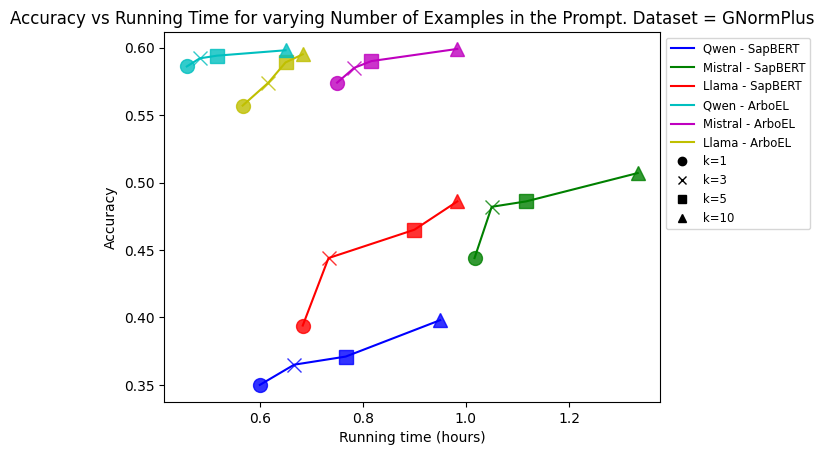

In [2]:
llama_acc_sapbert = [0.394, 0.444, 0.465, 0.486]
llama_time_sapbert = [41/60, 44/60, 54/60, 59/60]

mistral_acc_sapbert = [0.444, 0.482, 0.486, 0.507]
mistral_time_sapbert = [1+1/60, 1+3/60, 1+7/60, 1+20/60]

qwen_acc_sapbert = [0.350, 0.365, 0.371, 0.398]
qwen_time_sapbert = [36/60, 40/60, 46/60, 57/60]

llama_acc_arboel = [0.557, 0.574, 0.589, 0.595]
llama_time_arboel = [34/60, 37/60, 39/60, 41/60]

mistral_acc_arboel = [0.574, 0.585, 0.590, 0.599]
mistral_time_arboel = [45/60, 47/60, 49/60, 59/60]

qwen_acc_arboel = [0.586, 0.592, 0.594, 0.598]
qwen_time_arboel = [27.5/60, 29/60, 31/60, 39/60]

# Markers for each point index
markers = ['o', 'x', 's', '^']  # markers = ['o', 'x', 's', '^', 'D']  # Circle, cross, square, triangle, diamond
marker_meanings = ['k=1', 'k=3', 'k=5', 'k=10']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown']

# Create figure and axes
fig, ax = plt.subplots()

# Plot entire curves to connect the points with lines
ax.plot(qwen_time_sapbert, qwen_acc_sapbert, color=colors[0], linestyle='-', label='Qwen - SapBERT')
ax.plot(mistral_time_sapbert, mistral_acc_sapbert, color=colors[1], linestyle='-', label='Mistral - SapBERT')
ax.plot(llama_time_sapbert, llama_acc_sapbert, color=colors[2], linestyle='-', label='Llama - SapBERT')

ax.plot(qwen_time_arboel, qwen_acc_arboel, color=colors[3], linestyle='-', label='Qwen - ArboEL')
ax.plot(mistral_time_arboel, mistral_acc_arboel, color=colors[4], linestyle='-', label='Mistral - ArboEL')
ax.plot(llama_time_arboel, llama_acc_arboel, color=colors[5], linestyle='-', label='Llama - ArboEL') 

# Plot each point separately with shared markers for the same index across curves
for i in range(len(qwen_time_arboel)):
    ax.plot(qwen_time_sapbert[i], qwen_acc_sapbert[i], marker=markers[i], color=colors[0], linestyle='None', alpha=0.8, markersize=10)
    ax.plot(mistral_time_sapbert[i], mistral_acc_sapbert[i], marker=markers[i], color=colors[1], linestyle='None', alpha=0.8, markersize=10)
    ax.plot(llama_time_sapbert[i], llama_acc_sapbert[i], marker=markers[i], color=colors[2], linestyle='None', alpha=0.8, markersize=10)
    ax.plot(qwen_time_arboel[i], qwen_acc_arboel[i], marker=markers[i], color=colors[3], linestyle='None', alpha=0.8, markersize=10)
    ax.plot(mistral_time_arboel[i], mistral_acc_arboel[i], marker=markers[i], color=colors[4], linestyle='None', alpha=0.8, markersize=10)
    ax.plot(llama_time_arboel[i], llama_acc_arboel[i], marker=markers[i], color=colors[5], linestyle='None', alpha=0.8, markersize=10)

# Add separate legend entries for each marker type
for i, meaning in enumerate(marker_meanings):
    ax.plot([], [], marker=markers[i], color='black', linestyle='None', label=meaning)

# Adding labels and title
ax.set_xlabel('Running time (hours)')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs Running Time for varying Number of Examples in the Prompt. Dataset = GNormPlus')

# Adding a legend
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')

# Display the plot
plt.show()


## Effect of number of candidates in the prompt (GNormPlus)

In [ ]:
llama_acc_sapbert = [0.397, 0.470, 0.444, 0.417, 0.419, 0.412]
llama_time_sapbert = [30/60, 35/60, 43/60, 51/60, 60/60, 1+9/60]

mistral_acc_sapbert = [0.407, 0.500, 0.482, 0.480, 0.480, 0.451]
mistral_time_sapbert = [35/60, 50/60, 1+3/60, 1+15/60, 1+30/60, 1+38/60]

qwen_acc_sapbert = [0.317, 0.369, 0.365, 0.360, 0.343, 0.340]
qwen_time_sapbert = [21/60, 31/60, 40/60, 50/60, 59/60, 1+7/60]

llama_acc_arboel = [0.597, 0.582, 0.575, 0.579, 0.573, 0.571]
llama_time_arboel = [35.5/60, 36.3/60, 37/60, 38/60, 40/60, 47/60]

mistral_acc_arboel = [0.589, 0.578, 0.585, 0.579, 0.572, 0.573]
mistral_time_arboel = [37/60, 40/60, 47/60, 54/60, 62/60, 71/60]

qwen_acc_arboel = [0.601, 0.603, 0.593, 0.586, 0.582, 0.580]
qwen_time_arboel = [23/60, 26/60, 29/60, 34/60, 42/60, 44/60]

# Markers for each point index
markers = ['o', 'x', 's', '^', 'D', '*']  # Circle, cross, square, triangle, diamond, star
marker_meanings = ['c=5', 'c=10', 'c=20', 'c=30', 'c=40', 'c=50']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown']

# Create figure and axes
fig, ax = plt.subplots()

# Plot entire curves to connect the points with lines
ax.plot(qwen_time_sapbert, qwen_acc_sapbert, color=colors[0], linestyle='-', label='Qwen - SapBERT')
ax.plot(mistral_time_sapbert, mistral_acc_sapbert, color=colors[1], linestyle='-', label='Mistral - SapBERT')
ax.plot(llama_time_sapbert, llama_acc_sapbert, color=colors[2], linestyle='-', label='Llama - SapBERT')

ax.plot(qwen_time_arboel, qwen_acc_arboel, color=colors[3], linestyle='-', label='Qwen - ArboEL')
ax.plot(mistral_time_arboel, mistral_acc_arboel, color=colors[4], linestyle='-', label='Mistral - ArboEL')
ax.plot(llama_time_arboel, llama_acc_arboel, color=colors[5], linestyle='-', label='Llama - ArboEL') 

# Plot each point separately with shared markers for the same index across curves
for i in range(len(qwen_time_arboel)):
    ax.plot(qwen_time_sapbert[i], qwen_acc_sapbert[i], marker=markers[i], color=colors[0], linestyle='None', alpha=0.8, markersize=10)
    ax.plot(mistral_time_sapbert[i], mistral_acc_sapbert[i], marker=markers[i], color=colors[1], linestyle='None', alpha=0.8, markersize=10)
    ax.plot(llama_time_sapbert[i], llama_acc_sapbert[i], marker=markers[i], color=colors[2], linestyle='None', alpha=0.8, markersize=10)
    ax.plot(qwen_time_arboel[i], qwen_acc_arboel[i], marker=markers[i], color=colors[3], linestyle='None', alpha=0.8, markersize=10)
    ax.plot(mistral_time_arboel[i], mistral_acc_arboel[i], marker=markers[i], color=colors[4], linestyle='None', alpha=0.8, markersize=10)
    ax.plot(llama_time_arboel[i], llama_acc_arboel[i], marker=markers[i], color=colors[5], linestyle='None', alpha=0.8, markersize=10)

# Add separate legend entries for each marker type
for i, meaning in enumerate(marker_meanings):
    ax.plot([], [], marker=markers[i], color='black', linestyle='None', label=meaning)

# Adding labels and title
ax.set_xlabel('Running time (hours)')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs Running Time for varying Number of Candidates in the Prompt. Dataset = GNormplus')

# Adding a legend
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')

# Display the plot
plt.show()


## Effect of number of candidates in the prompt (NLM-Gene)

In [ ]:
llama_acc_sapbert = [0.208, 0.288, 0.314, 0.285, 0.294, 0.283]
llama_time_sapbert = [19/60, 25/60, 40/60, 43/60, 49/60, 57/60]

mistral_acc_sapbert = [0.217, 0.302, 0.340, 0.327, 0.316, 0.314]
mistral_time_sapbert = [25/60, 35/60, 53/60, 1+10/60, 1+19/60, 1+30/60]

qwen_acc_sapbert = [0.174, 0.236, 0.251, 0.234, 0.230, 0.225]
qwen_time_sapbert = [18/60, 23/60, 37/60, 45/60, 52/60, 56/60]

llama_acc_arboel = [0.597, 0.543, 0.549, 0.579, 0.573, 0.559]
llama_time_arboel = [37/60, 38.5/60, 40/60, 42/60, 45/60, 52/60]

mistral_acc_arboel = [0.552, 0.541, 0.549, 0.553, 0.554, 0.550]
mistral_time_arboel = [38/60, 46/60, 48/60, 54/60, 62/60, 71/60]

qwen_acc_arboel = [0.556, 0.558, 0.549, 0.556, 0.553, 0.546]
qwen_time_arboel = [29/60, 31/60, 35/60, 41/60, 48/60, 60/60]

# Markers for each point index
markers = ['o', 'x', 's', '^', 'D', '*']  # Circle, cross, square, triangle, diamond, star
marker_meanings = ['c=5', 'c=10', 'c=20', 'c=30', 'c=40', 'c=50']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown']

# Create figure and axes
fig, ax = plt.subplots()

# Plot entire curves to connect the points with lines
ax.plot(qwen_time_sapbert, qwen_acc_sapbert, color=colors[0], linestyle='-', label='Qwen - SapBERT')
ax.plot(mistral_time_sapbert, mistral_acc_sapbert, color=colors[1], linestyle='-', label='Mistral - SapBERT')
ax.plot(llama_time_sapbert, llama_acc_sapbert, color=colors[2], linestyle='-', label='Llama - SapBERT')

ax.plot(qwen_time_arboel, qwen_acc_arboel, color=colors[3], linestyle='-', label='Qwen - ArboEL')
ax.plot(mistral_time_arboel, mistral_acc_arboel, color=colors[4], linestyle='-', label='Mistral - ArboEL')
ax.plot(llama_time_arboel, llama_acc_arboel, color=colors[5], linestyle='-', label='Llama - ArboEL') 

# Plot each point separately with shared markers for the same index across curves
for i in range(len(qwen_time_arboel)):
    ax.plot(qwen_time_sapbert[i], qwen_acc_sapbert[i], marker=markers[i], color=colors[0], linestyle='None', alpha=0.8, markersize=10)
    ax.plot(mistral_time_sapbert[i], mistral_acc_sapbert[i], marker=markers[i], color=colors[1], linestyle='None', alpha=0.8, markersize=10)
    ax.plot(llama_time_sapbert[i], llama_acc_sapbert[i], marker=markers[i], color=colors[2], linestyle='None', alpha=0.8, markersize=10)
    ax.plot(qwen_time_arboel[i], qwen_acc_arboel[i], marker=markers[i], color=colors[3], linestyle='None', alpha=0.8, markersize=10)
    ax.plot(mistral_time_arboel[i], mistral_acc_arboel[i], marker=markers[i], color=colors[4], linestyle='None', alpha=0.8, markersize=10)
    ax.plot(llama_time_arboel[i], llama_acc_arboel[i], marker=markers[i], color=colors[5], linestyle='None', alpha=0.8, markersize=10)

# Add separate legend entries for each marker type
for i, meaning in enumerate(marker_meanings):
    ax.plot([], [], marker=markers[i], color='black', linestyle='None', label=meaning)

# Adding labels and title
ax.set_xlabel('Running time (hours)')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs Running Time for varying Number of Candidates in the Prompt. Dataset = NLM-Gene')

# Adding a legend
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')

# Display the plot
plt.show()


## Number of mentions vs running time for the different models

In [ ]:
X = [860, 2124, 2692, 10337, 31827] # Dataset size : Number of evaluated mentions

# gpt4o_mini_time_sapbert = [11/60, 38/60, 70/60, 2 + 20/60]

# gpt4o_time_sapbert = [12/60, 28/60, 39/60, 2 + 10/60]

llama_time_sapbert = [14/60, 33/60, 43/60, 3 + 31/60, 5 + 32/60]

mistral_time_sapbert = [20/60, 51/60, 60/60, 3 + 45/60, 10 + 47/60]

qwen_time_sapbert = [11/60, 31/60, 40/60, 3 + 21/60, 6 + 0/60]

# Markers for each point index
markers = ['o', 'x', 's', '^', 'D']  # markers = ['o', 'x', 's', '^', 'D']  # Circle, cross, square, triangle, diamond
marker_meanings = ['NCBI-Disease', 'NLM-Gene', 'GNormPlus', 'NLMChem', 'MM-ST21PV']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown']

# Create figure and axes
fig, ax = plt.subplots()

# Plot entire curves to connect the points with lines
# ax.plot(gpt4o_mini_time_sapbert, X[:4], color=colors[1], linestyle='-', label='gpt-4o-mini')
# ax.plot(gpt4o_time_sapbert, X[:4], color=colors[2], linestyle='-', label='gpt-4o')
ax.plot(qwen_time_sapbert, X, color=colors[3], linestyle='-', label='Qwen')
ax.plot(mistral_time_sapbert, X, color=colors[4], linestyle='-', label='Mistral')
ax.plot(llama_time_sapbert, X, color=colors[5], linestyle='-', label='Llama') 

# Plot each point separately with shared markers for the same index across curves
for i in range(len(qwen_time_sapbert)):
    # if i < len(gpt4o_mini_time_sapbert) :
    #     ax.plot(gpt4o_mini_time_sapbert[i], X[i], marker=markers[i], color=colors[1], linestyle='None', alpha=0.8, markersize=8)
    # if i < len(gpt4o_time_sapbert):
    #     ax.plot(gpt4o_time_sapbert[i], X[i], marker=markers[i], color=colors[2], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(qwen_time_sapbert[i], X[i], marker=markers[i], color=colors[3], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(mistral_time_sapbert[i], X[i], marker=markers[i], color=colors[4], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(llama_time_sapbert[i], X[i], marker=markers[i], color=colors[5], linestyle='None', alpha=0.8, markersize=8)

# Add separate legend entries for each marker type
for i, meaning in enumerate(marker_meanings):
    ax.plot([], [], marker=markers[i], color='black', linestyle='None', label=meaning)

# Adding labels and title
ax.set_xlabel('Running time (hours)')
ax.set_ylabel('Number of mentions')
ax.set_title('Number of Mentions vs Running Time for Accuracy across Different LLMs. Base model = SapBERT')

# Set logarithmic scale for both x and y axes
ax.set_xscale('log')
# ax.set_yscale('log')

# Adding a legend
ax.legend()

# Display the plot
plt.show()


In [ ]:
X = [860, 2124, 2692, 10337, 31827] # Dataset size : Number of evaluated mentions

llama_time_sapbert = [30/60, 1 + 40/60, 1 + 30/60, 3 + 5 + 30/60, 12 + 41/60]

mistral_time_sapbert = [30/60, 2 + 8/60, 2 + 30/60, 3 + 8 + 29/60, 23 + 21/60]

qwen_time_sapbert = [23/60, 45/60, 1 + 40/60, 3 + 5 + 40/60, 14 + 20/60]

# gpt4o_mini_time_sapbert = [13/60, 45/60, 1 + 30/60, 4 + 0/60]

# gpt4o_time_sapbert = [16/60, 41/60, 55/60, 4 + 0/60]

# Markers for each point index
markers = ['o', 'x', 's', '^', 'D']  # markers = ['o', 'x', 's', '^', 'D']  # Circle, cross, square, triangle, diamond
marker_meanings = ['NCBI-Disease', 'NLM-Gene', 'GNormPlus', 'NLMChem', 'MM-ST21PV']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown']

# Create figure and axes
fig, ax = plt.subplots()

# Plot entire curves to connect the points with lines
# ax.plot(gpt4o_mini_time_sapbert, X[:4], color=colors[1], linestyle='-', label='gpt-4o-mini')
# ax.plot(gpt4o_time_sapbert, X[:4], color=colors[2], linestyle='-', label='gpt-4o')
ax.plot(qwen_time_sapbert, X, color=colors[3], linestyle='-', label='Qwen')
ax.plot(mistral_time_sapbert, X, color=colors[4], linestyle='-', label='Mistral')
ax.plot(llama_time_sapbert, X, color=colors[5], linestyle='-', label='Llama') 

# Plot each point separately with shared markers for the same index across curves
for i in range(len(qwen_time_sapbert)):
    # if i < len(gpt4o_mini_time_sapbert) :
    #     ax.plot(gpt4o_mini_time_sapbert[i], X[i], marker=markers[i], color=colors[1], linestyle='None', alpha=0.8, markersize=8)
    # if i < len(gpt4o_time_sapbert):
    #     ax.plot(gpt4o_time_sapbert[i], X[i], marker=markers[i], color=colors[2], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(qwen_time_sapbert[i], X[i], marker=markers[i], color=colors[3], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(mistral_time_sapbert[i], X[i], marker=markers[i], color=colors[4], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(llama_time_sapbert[i], X[i], marker=markers[i], color=colors[5], linestyle='None', alpha=0.8, markersize=8)

# Add separate legend entries for each marker type
for i, meaning in enumerate(marker_meanings):
    ax.plot([], [], marker=markers[i], color='black', linestyle='None', label=meaning)

# Adding labels and title
ax.set_xlabel('Running time (hours)')
ax.set_ylabel('Number of mentions')
ax.set_title('Number of Mentions vs Running Time for Recall@5 across Different LLMs. Base model = SapBERT')

# Set logarithmic scale for both x and y axes
ax.set_xscale('log')
# ax.set_yscale('log')

# Adding a legend
ax.legend()

# Display the plot
plt.show()


In [ ]:
# Running time vs number of mentions accuracy

X = [860, 2124, 2692, 10337, 31827] # Dataset size : Number of evaluated mentions

# gpt4o_mini_time_sapbert = [11/60, 38/60, 70/60, 2 + 20/60]

# gpt4o_time_sapbert = [12/60, 28/60, 39/60, 2 + 10/60]

llama_time_sapbert = [14/60, 33/60, 43/60, 3 + 31/60, 5 + 32/60]

mistral_time_sapbert = [20/60, 51/60, 60/60, 3 + 45/60, 10 + 47/60]

qwen_time_sapbert = [11/60, 31/60, 40/60, 3 + 21/60, 6 + 0/60]

# Markers for each point index
markers = ['o', 'x', 's', '^', 'D']  # markers = ['o', 'x', 's', '^', 'D']  # Circle, cross, square, triangle, diamond
marker_meanings = ['NCBI-Disease', 'NLM-Gene', 'GNormPlus', 'NLMChem', 'MM-ST21PV']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown']

# Create figure and axes
fig, ax = plt.subplots()

# Plot entire curves to connect the points with lines
# ax.plot(gpt4o_mini_time_sapbert, X[:4], color=colors[1], linestyle='-', label='gpt-4o-mini')
# ax.plot(gpt4o_time_sapbert, X[:4], color=colors[2], linestyle='-', label='gpt-4o')
ax.plot(X, qwen_time_sapbert, color=colors[3], linestyle='-', label='Qwen')
ax.plot(X, mistral_time_sapbert, color=colors[4], linestyle='-', label='Mistral')
ax.plot(X, llama_time_sapbert, color=colors[5], linestyle='-', label='Llama') 

# Plot each point separately with shared markers for the same index across curves
for i in range(len(qwen_time_sapbert)):
    # if i < len(gpt4o_mini_time_sapbert) :
    #     ax.plot(gpt4o_mini_time_sapbert[i], X[i], marker=markers[i], color=colors[1], linestyle='None', alpha=0.8, markersize=8)
    # if i < len(gpt4o_time_sapbert):
    #     ax.plot(gpt4o_time_sapbert[i], X[i], marker=markers[i], color=colors[2], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(X[i], qwen_time_sapbert[i], marker=markers[i], color=colors[3], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(X[i], mistral_time_sapbert[i], marker=markers[i], color=colors[4], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(X[i], llama_time_sapbert[i], marker=markers[i], color=colors[5], linestyle='None', alpha=0.8, markersize=8)

# Add separate legend entries for each marker type
for i, meaning in enumerate(marker_meanings):
    ax.plot([], [], marker=markers[i], color='black', linestyle='None', label=meaning)

# Adding labels and title
ax.set_xlabel('Number of Evaluated Mentions')
ax.set_ylabel('Running time (hours)')
ax.set_title('Running Time vs Number of Mentions for Accuracy across Different LLMs. Base model = SapBERT')

# Set logarithmic scale for both x and y axes
# ax.set_xscale('log')
ax.set_yscale('log')

# Adding a legend
ax.legend()

# Display the plot
plt.show()


In [ ]:
# Running time vs number of mentions recall@5

X = [860, 2124, 2692, 10337, 31827] # Dataset size : Number of evaluated mentions

llama_time_sapbert = [30/60, 1 + 40/60, 1 + 30/60, 3 + 5 + 30/60, 12 + 41/60]

mistral_time_sapbert = [30/60, 2 + 8/60, 2 + 30/60, 3 + 8 + 29/60, 23 + 21/60]

qwen_time_sapbert = [23/60, 45/60, 1 + 40/60, 3 + 5 + 40/60, 14 + 20/60]

# gpt4o_mini_time_sapbert = [13/60, 45/60, 1 + 30/60, 4 + 0/60]

# gpt4o_time_sapbert = [16/60, 41/60, 55/60, 4 + 0/60]

# Markers for each point index
markers = ['o', 'x', 's', '^', 'D']  # markers = ['o', 'x', 's', '^', 'D']  # Circle, cross, square, triangle, diamond
marker_meanings = ['NCBI-Disease', 'NLM-Gene', 'GNormPlus', 'NLMChem', 'MM-ST21PV']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown']

# Create figure and axes
fig, ax = plt.subplots()

# Plot entire curves to connect the points with lines
# ax.plot(gpt4o_mini_time_sapbert, X[:4], color=colors[1], linestyle='-', label='gpt-4o-mini')
# ax.plot(gpt4o_time_sapbert, X[:4], color=colors[2], linestyle='-', label='gpt-4o')
ax.plot(X, qwen_time_sapbert, color=colors[3], linestyle='-', label='Qwen')
ax.plot(X, mistral_time_sapbert, color=colors[4], linestyle='-', label='Mistral')
ax.plot(X, llama_time_sapbert, color=colors[5], linestyle='-', label='Llama') 

# Plot each point separately with shared markers for the same index across curves
for i in range(len(qwen_time_sapbert)):
    # if i < len(gpt4o_mini_time_sapbert) :
    #     ax.plot(gpt4o_mini_time_sapbert[i], X[i], marker=markers[i], color=colors[1], linestyle='None', alpha=0.8, markersize=8)
    # if i < len(gpt4o_time_sapbert):
    #     ax.plot(gpt4o_time_sapbert[i], X[i], marker=markers[i], color=colors[2], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(X[i], qwen_time_sapbert[i], marker=markers[i], color=colors[3], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(X[i], mistral_time_sapbert[i], marker=markers[i], color=colors[4], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(X[i], llama_time_sapbert[i], marker=markers[i], color=colors[5], linestyle='None', alpha=0.8, markersize=8)

# Add separate legend entries for each marker type
for i, meaning in enumerate(marker_meanings):
    ax.plot([], [], marker=markers[i], color='black', linestyle='None', label=meaning)

# Adding labels and title
ax.set_xlabel('Number of Evaluated Mentions')
ax.set_ylabel('Running time (hours)')
ax.set_title('Running Time vs Number of Mentions for Recall@5 across Different LLMs. Base model = SapBERT')

# Set logarithmic scale for both x and y axes
# ax.set_xscale('log')
ax.set_yscale('log')

# Adding a legend
ax.legend()

# Display the plot
plt.show()


# Error Analysis for revision

# DEPRECATED
# vllm + aqlm 


In [ ]:
llm = LLM(
    model="ISTA-DASLab/Mixtral-8x7B-Instruct-v0_1-AQLM-2Bit-1x16-hf",
    enforce_eager=True,
)

tokenizer = llm.get_tokenizer()

In [ ]:
# def prompt_vllm_aqlm(mention, context, system_instructions, candidates, topk_examples, llm, tokenizer, sampling_params):
#     ''' 
#     mention : str (name of the mention to be linked)
#     context : str (context where the mention appears)
#     system_instructions : str (instructions for the LLM)
#     candidates : list of list of CUIs : [[cui1], [cui2, cui3], ...]
#     topk_examples : str (top k examples of similar contexts)
#     llm : LLM model
#     tokenizer : AutoTokenizer
#     sampling_params : SamplingParams config
#     '''
    
#     prompt_text = f"""
#     System Instructions: {system_instructions} \n
    
#     Here are a few examples: \n
#     {topk_examples} \n

#     This is the specific mention that needs to be linked to the correct entity: {mention} \n

#     This is the context where the mention appears: \n
#     {context} \n
    
#     These are the candidate entities to choose from: \n
#     {candidates} \n
    
#     You MUST PROVIDE an ANSWER among the candidates. \n

#     Return the answer in the following format: CUI
#     For instance : "MESH:D000000" "OMIM:000000" are valid answers. \n
#     Do not add provide any explanations ! But you MUST give ONE answer.
#     """
#     conversations = tokenizer.apply_chat_template(
#         [{'role': 'user', 'content': prompt_text}],
#         tokenize=False,
#     )

#     # Decode the generated tokens into text
#     outputs = llm.generate([conversations], sampling_params=sampling_params, use_tqdm=False)
#     answer = outputs[0].outputs[0].text

#     return answer


In [ ]:
mention = "9931324.1"
text = mention2text[mention]
context = mention2context[mention]
candidates = get_candidates_data(mention2biencoder_candidates[mention], ontology2)
topk = topk_examples(model = model,
                    index = index,
                    query=context, 
                    corpus=corpus, 
                    TrainMap_context2mention=TrainMap_context2mention, 
                    train_mention2text=train_mention2text, 
                    train_mention2gold=train_mention2gold, 
                    ontology=ontology2, 
                    k=3)

pred_cui = prompt_vllm_aqlm(mention=text, 
                       context=context, 
                       system_instructions=system_instructions,
                       candidates=candidates, 
                       topk_examples=topk,
                       llm=llm,
                       tokenizer=tokenizer,
                       sampling_params=sampling_params)

# Output the results
print("Mention ID:", mention)
print("Context:", context)
print("Top k examples:", topk)
print("Text:", mention2text[mention])
print("Gold CUI:", mention2gold[mention])
print("Predicted CUI:", pred_cui)

In [ ]:
# def evaluate_vllm_aqlm(
#     llm,
#     nlp_model,
#     tokenizer,
#     index,
#     system_instructions,
#     mentions,
#     ontology,
#     corpus,
#     mention2context,
#     mention2biencoder_candidates,
#     mention2text,
#     TrainMap_context2mention,
#     train_mention2text,
#     train_mention2gold,
#     k,
#     sampling_params,
# ):
#     """
#     Run "prompt" function for each mention in the list of mentions.
#     Returns a dictionary {mention_id : predicted CUI}
#     -------
#     llm : LLM model
#     nlp_model : SentenceTransformer model
#     tokenizer : AutoTokenizer
#     index : faiss index
#     system_instructions : str (instructions for the LLM)
#     mentions : list (mention_ids)
#     ontology : BiomedicalOntology object
#     corpus : list of str (all context sentences)
#     mention2context : dict (mention_id : context)
#     mention2biencoder_candidates : dict (mention_id : list of candidate CUIs)
#     mention2text : dict (mention_id : mention name)
#     TrainMap_context2mention : dict (context sentence to mention_id)
#     train_mention2text : dict (mention_id to mention name)
#     train_mention2gold : dict (mention_id to gold CUI)
#     k : int (number of nearest neighbors)
#     sampling_params : SamplingParams config
#     """
#     results = {}
#     for i in range(len(mentions)) :
#         mention_id = mentions[i]
#         mention_name = mention2text[mention_id]
#         context = mention2context[mention_id]
#         candidates = get_candidates_data(mention2biencoder_candidates[mentions[i]], ontology)
#         # candidates = get_candidates_data_v2(mention2arboel_candidates[mention])
#         topk = topk_examples(
#             model=nlp_model,  # sentence transformer model
#             index=index,
#             query=context,
#             corpus=corpus,
#             TrainMap_context2mention=TrainMap_context2mention,
#             train_mention2text=train_mention2text,
#             train_mention2gold=train_mention2gold,
#             ontology=ontology,
#             k=k,
#         )
#         text = prompt_vllm_aqlm(
#             mention=mention_name,
#             context=context,
#             system_instructions=system_instructions,
#             candidates=candidates,
#             topk_examples=topk,
#             llm=llm,
#             tokenizer=tokenizer,
#             sampling_params=sampling_params,
#         )
#         print("mention ID :", mention_id , "|| LLM answer :", text)
#         cand = extract_cui(text)
#         results[mention_id] = cand
#         if i%20 == 0:
#             print(f"i = {i}")

#     return results
    


In [ ]:
results = evaluate_vllm_aqlm(llm=llm,
                        nlp_model=model,
                        tokenizer=tokenizer,
                        index=index,
                        system_instructions=system_instructions,
                        mentions=mentions[:5],
                        ontology=ontology2,
                        corpus=corpus,
                        mention2context=mention2context,
                        mention2biencoder_candidates=mention2biencoder_candidates,
                        mention2text=mention2text,
                        TrainMap_context2mention=TrainMap_context2mention,
                        train_mention2text=train_mention2text,
                        train_mention2gold=train_mention2gold,
                        k=10,
                        sampling_params=sampling_params)
results

In [ ]:
results

In [ ]:
score = scoring(results=results, mention2gold=mention2gold)
score

In [ ]:
from vllm import LLM, SamplingParams
import torch

sampling_params = SamplingParams(temperature=0, top_p=0.9, max_tokens=1000, stop=["<|eot_id|>"])

device_1 = torch.device("cuda:0")

llm = LLM(
model="meta-llama/Meta-Llama-3.1-8B-Instruct",
tensor_parallel_size=1,
dtype = "half",
gpu_memory_utilization=0.8,
max_logprobs=1000,
device=device_1,
max_model_len = 30000)

tokenizer = llm.get_tokenizer()

def prompt_vllm(system_instructions, llm, tokenizer, sampling_params, prompt):
    """
    system_instructions : str (instructions for the LLM)
    llm : LLM model
    tokenizer : AutoTokenizer
    sampling_params : SamplingParams config
    prompt : str (prompt text)
    """
    messages = [
        {"role": "system", "content": system_instructions},
        {"role": "user", "content": prompt},
    ]
    prompts = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    # Decode the generated tokens into text
    outputs = llm.generate(prompts=prompts, sampling_params=sampling_params)
    answer = outputs[0].outputs[0].text

    return answer

In [ ]:
answer = prompt_vllm(system_instructions=None, llm=llm, tokenizer=tokenizer, sampling_params=sampling_params, prompt="Describe in one sentence what a cat is.")
answer

# TEST BIOEL
# TEST BIOEL
# TEST BIOEL
# TEST BIOEL
# TEST BIOEL

# Merge base model with lora adapter for loading the model using vllm

In [ ]:
from transformers import AutoModelForCausalLM
from peft import PeftModel

# 1. Load the *base* model
base_model_name = "Qwen/Qwen2.5-7B-Instruct"
base_model = AutoModelForCausalLM.from_pretrained(base_model_name, torch_dtype="auto")

# 2. Load your LoRA adapter on top of the base model
peft_model_path = "./trained_model_nlmchem_v2"  # where you ran save_pretrained()
lora_model = PeftModel.from_pretrained(base_model, peft_model_path, torch_dtype="auto")

# 3. Merge the LoRA weights into the base model
merged_model = lora_model.merge_and_unload()

# 4. Now save the merged model as safetensors
#    (this is critical, so vLLM sees *one* final checkpoint without separate LoRA)
merged_model.save_pretrained(
    "./trained_model_nlmchem_v3",
    safe_serialization=True   # This writes safetensors instead of .bin
)

In [32]:
! pip uninstall bioel -y

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Found existing installation: bioel 0.1.4
Uninstalling bioel-0.1.4:
  Successfully uninstalled bioel-0.1.4


In [33]:
pip install bioel


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  Using cached bioel-0.1.4-cp39-cp39-linux_x86_64.whl
  Using cached numpy-2.0.2-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
  Using cached numpy-1.26.4-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.2 MB)
    PyYAML (>=5.1.*)
            ~~~~~~^
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fairseq 0.12.2 requires omegaconf<2.1, which is not installed.
tensorflow-gpu 2.5.1 requires numpy~=1.19.2, but you have numpy 1.26.4 which is incompatible.
tensorflow-gpu 2.5.1 requires typing-extensions~=3.7.4, but you have typing-extensions 4.12.2 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [31]:
pip uninstall numpy -y

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install numpy==1.23


  Using cached numpy-1.23.0-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.2 kB)
Using cached numpy-1.23.0-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.1 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
faiss-cpu 1.9.0.post1 requires numpy<3.0,>=1.25.0, but you have numpy 1.23.0 which is incompatible.
tensorflow-gpu 2.5.1 requires numpy~=1.19.2, but you have numpy 1.23.0 which is incompatible.
tensorflow-gpu 2.5.1 requires typing-extensions~=3.7.4, but you have typing-extensions 4.12.2 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [2]:
from bioel.evaluate import Evaluate
from bioel.model import BioEL_Model

/nethome/cye73/conda_envs/bent/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[28/Jan/2025 19:08:05] INFO - Better speed can be achieved with apex installed from https://www.github.com/nvidia/apex .
[28/Jan/2025 19:08:05] INFO - Better speed can be achieved with apex installed from https://www.github.com/nvidia/apex .
[28/Jan/2025 19:08:05] INFO - Loading faiss with AVX512 support.
[28/Jan/2025 19:08:05] INFO - Successfully loaded faiss with AVX512 support.


2025-01-28 19:08:05.658773: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2025-01-28 19:08:05.658801: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


AttributeError: module 'numpy' has no attribute 'typeDict'

/nethome/cye73/conda_envs/bent/lib/python3.9/site-packages/tensorflow/python/framework/dtypes.py:511: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  np.object,


RuntimeError: Failed to import transformers.trainer_seq2seq because of the following error (look up to see its traceback):
Failed to import transformers.integrations.integration_utils because of the following error (look up to see its traceback):
Failed to import transformers.modeling_tf_utils because of the following error (look up to see its traceback):
module 'numpy' has no attribute 'object'.
`np.object` was a deprecated alias for the builtin `object`. To avoid this error in existing code, use `object` by itself. Doing this will not modify any behavior and is safe. 
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations

In [3]:
import numpy
print(numpy.__version__) 

1.26.4


In [29]:
! git clone https://github.com/pytorch/fairseq

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Cloning into 'fairseq'...
remote: Enumerating objects: 35391, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 35391 (delta 7), reused 5 (delta 5), pack-reused 35375 (from 3)
Receiving objects: 100% (35391/35391), 25.48 MiB | 46.01 MiB/s, done.
Resolving deltas: 100% (25540/25540), done.


In [1]:
from bioel.dataset import Dataset


/nethome/cye73/conda_envs/test_bioel/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
abbreviations_path = "/home2/cye73/data_test/abbreviations.json"
dataset_name = "bc5cdr" # Specify the desired dataset name from the BigBio collection here.
dataset = Dataset(
    dataset_name = dataset_name, abbreviations_path=abbreviations_path
)

Resolved abbreviations


In [3]:
dir(dataset)

['__add__',
 '__class__',
 '__class_getitem__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__orig_bases__',
 '__parameters__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_is_protocol',
 'abbreviations_path',
 'data',
 'dataset_name',
 'df',
 'documents',
 'name_to_cuis',
 'splits']

In [4]:
dataset.data['train']['entities']

[[{'deabbreviated_text': 'Naloxone',
   'id': '3',
   'normalized': [{'db_id': 'D009270', 'db_name': 'MESH'}],
   'offsets': [[0, 8]],
   'text': ['Naloxone'],
   'type': 'Chemical'},
  {'deabbreviated_text': 'clonidine',
   'id': '4',
   'normalized': [{'db_id': 'D003000', 'db_name': 'MESH'}],
   'offsets': [[49, 58]],
   'text': ['clonidine'],
   'type': 'Chemical'},
  {'deabbreviated_text': 'hypertensive',
   'id': '5',
   'normalized': [{'db_id': 'D006973', 'db_name': 'MESH'}],
   'offsets': [[93, 105]],
   'text': ['hypertensive'],
   'type': 'Disease'},
  {'deabbreviated_text': 'clonidine',
   'id': '6',
   'normalized': [{'db_id': 'D003000', 'db_name': 'MESH'}],
   'offsets': [[181, 190]],
   'text': ['clonidine'],
   'type': 'Chemical'},
  {'deabbreviated_text': 'nalozone',
   'id': '7',
   'normalized': [],
   'offsets': [[244, 252]],
   'text': ['nalozone'],
   'type': 'Chemical'},
  {'deabbreviated_text': 'hypotensive',
   'id': '8',
   'normalized': [{'db_id': 'D007022', 'd

In [5]:
from bioel.ontology import BiomedicalOntology
dataset_name = 'ncbi_disease'
medic_dict = {"name" : "medic",
            "filepath" : "/mitchell/entity-linking/kbs/medic.tsv"} # medic.tsv file

ontology = BiomedicalOntology.load_medic(**medic_dict)

[2025-02-02 10:05:06] [ontology.py] [INFO] Reading entrez from /mitchell/entity-linking/kbs/medic.tsv


In [16]:
dir(ontology)

['__annotations__',
 '__class__',
 '__dataclass_fields__',
 '__dataclass_params__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'abbrev',
 'dataset',
 'entities',
 'get_aliases',
 'get_canonical_name',
 'get_definition',
 'get_types',
 'load_csv',
 'load_entrez',
 'load_json',
 'load_medic',
 'load_mesh',
 'load_ncbi_taxon',
 'load_obo',
 'load_umls',
 'metadata',
 'name',
 'types']

In [6]:
ontology.entities

{'MESH:C538288': BiomedicalEntity(cui='MESH:C538288', name='10p Deletion Syndrome (Partial)', types='Disease', aliases='Chromosome 10, 10p- Partial|Chromosome 10, monosomy 10p|Chromosome 10, Partial Deletion (short arm)|Monosomy 10p', definition='', equivalant_cuis=['MESH:C538288'], taxonomy=None, metadata=None),
 'MESH:C535484': BiomedicalEntity(cui='MESH:C535484', name='13q deletion syndrome', types='Disease', aliases="Chromosome 13q deletion|Chromosome 13q deletion syndrome|Chromosome 13q monosomy|Chromosome 13q syndrome|Deletion 13q|Deletion 13q syndrome|Monosomy 13q|Monosomy 13q syndrome|Orbeli's syndrome|Orbeli syndrome", definition='', equivalant_cuis=['MESH:C535484'], taxonomy=None, metadata=None),
 'MESH:C579849': BiomedicalEntity(cui='MESH:C579849', name='15q24 Microdeletion', types='Disease', aliases='15q24 Deletion|15q24 Microdeletion Syndrome|Interstitial Deletion of Chromosome 15q24', definition='', equivalant_cuis=['MESH:C579849'], taxonomy=None, metadata=None),
 'MESH:C

In [31]:
dataset_name = 'nlmchem'
path1 = f'/home/cye73/llm_disambiguator/src/raw_results/{dataset_name}/sapbert/accuracy/Qwen2.5-7B-Instruct_reasoning=True_k=3_cands=20_recall=False5_version=v1.json.jsonl'
path2 = f'/home/cye73/llm_disambiguator/src/raw_results/{dataset_name}/sapbert/accuracy/Qwen2.5-7B-Instruct_reasoning=True_k=3_cands=20_recall=False5_version=v2.json.jsonl'
path3 = f'/home/cye73/llm_disambiguator/src/raw_results/{dataset_name}/sapbert/accuracy/Qwen2.5-7B-Instruct_reasoning=True_k=3_cands=20_recall=False5_version=v3.json.jsonl'
path4 = f'/home/cye73/llm_disambiguator/src/raw_results/{dataset_name}/sapbert/accuracy/Qwen2.5-7B-Instruct_reasoning=True_k=3_cands=20_recall=False5_version=v4.json.jsonl'
path5 = f'/home/cye73/llm_disambiguator/src/raw_results/{dataset_name}/sapbert/accuracy/Qwen2.5-7B-Instruct_reasoning=True_k=3_cands=20_recall=False5_version=v5.json.jsonl'

with open(path1, 'r') as f1:
    data1 = [json.loads(line) for line in f1]

with open(path2, 'r') as f2:
    data2 = [json.loads(line) for line in f2]
    
with open(path3, 'r') as f3:
    data3 = [json.loads(line) for line in f3]
    
with open(path4, 'r') as f4:
    data4 = [json.loads(line) for line in f4]
    
with open(path5, 'r') as f5:
    data5 = [json.loads(line) for line in f5]


In [32]:
print(len(data1), len(data2), len(data3), len(data4), len(data5))
data1[0]

1500 2500 2500 2000 1837


{'pmid': '1325037.1',
 'llm_output': 'Let\'s analyze the mention "67Gallium" within the provided context step-by-step:\n\n1. **Context Analysis**:\n   - The mention "67Gallium" appears in the context of medical procedures, specifically a "67Gallium scan."\n   - This suggests that "67Gallium" is likely a medical imaging agent or a radioactive isotope used in medical diagnostics.\n\n2. **Candidate Entity Evaluation**:\n   - **MESH:D005708**: Gallium (atomic number 31, symbol Ga, atomic weight 69.72) - This is the general element Gallium, not a specific isotope or imaging agent.\n   - **MESH:D032061**: Galium - This is a genus of plants, not relevant to medical imaging.\n   - **MESH:D005709**: Gallium Isotopes - This is a general term for isotopes of Gallium, but it does not specify which isotope.\n   - **MESH:D005710**: Gallium Radioisotopes - This is a general term for radioactive isotopes of Gallium, but it does not specify which isotope.\n   - **MESH:C103850**: gallium citrate - This 

In [33]:
data = data1 
pmids_data1 = [d['pmid'] for d in data]
pmids_data = pmids_data1

In [34]:
for item in data2:
    if item['pmid'] not in pmids_data:
        data.append(item)
        pmids_data.append(item['pmid'])

for item in data3:
    if item['pmid'] not in pmids_data:
        data.append(item)
        pmids_data.append(item['pmid'])
        
for item in data4:
    if item['pmid'] not in pmids_data:
        data.append(item)
        pmids_data.append(item['pmid'])
        
for item in data5:
    if item['pmid'] not in pmids_data:
        data.append(item)
        pmids_data.append(item['pmid'])

In [35]:
len(data)

10337

In [36]:
path = f'/home/cye73/llm_disambiguator/src/raw_results/{dataset_name}/sapbert/accuracy/Qwen2.5-7B-Instruct_reasoning=True_k=3_cands=20_recall=False5_version=v0.json.jsonl'
with open(path, 'w') as f:
    for item in data:
        f.write(json.dumps(item) + '\n')

In [37]:
results = {}
for item in data : 
    pmid = item['pmid']
    cand = extract_last_cui(item['llm_output'])
    results[pmid] = {
                "predicted": cand,
                "gold": mention2gold[pmid],
                "explanation": item['llm_output'],
            }


In [38]:
path_result = f'/home/cye73/llm_disambiguator/src/results/{dataset_name}/sapbert/accuracy/Qwen2.5-7B-Instruct_reasoning=True_k=3_cands=20_recall=False5_version=v0.json'
with open(path_result, 'w') as f:
    json.dump(results, f)

In [44]:
k = 20
number_hits = {"arboel": number_hits_arboel,
               "sapbert": number_hits_sapbert}
score, match, nb_cands, errors = scoring(results = results, mention2gold = mention2gold)
print("Number of mentions:", total_mentions)
# Number of candidates - the number of mentions where the answer is 'None' because of token limits imposed by the LLM
print("Number of mentions in the results :", len(results))
print("Number of evaluated candidates:", nb_cands)
print("Number of mentions being ignored because not correctly formatted by the LLM:", errors)
print("Number of correct predictions:",match)
print("Accuracy :", score)
if EL_model == "sapbert":
    print("Normalized accuracy:", 
          score * sapbert_results[k-1][0])
elif EL_model == "arboel":
    print("Normalized accuracy:", 
          score * arboel_results[k-1][0])
print("path :", path)


Number of mentions: 2729
Number of mentions in the results : 2248
Number of evaluated candidates: 2248
Number of mentions being ignored because not correctly formatted by the LLM: 0
Number of correct predictions: 432
Accuracy : 0.19217081850533807
Normalized accuracy: 0.158299743495786


NameError: name 'path' is not defined

In [ ]:
# Read .log file

import re
import ast

# Initialize the results dictionary
results = {}

# Regular expression pattern to extract mention ID, gold, and LLM answer
pattern = re.compile(
    r"mention ID\s*:\s*(\S+)\s*\|\|\s*gold\s*:\s*(\[[^\]]+\])\s*\|\|\s*LLM answer\s*:\s*(\S+)"
)

# Path to your log file
log_file = "run_logs/llm10.log"

with open(log_file, "r") as f:
    for line in f:
        match = pattern.search(line)
        if match:
            mention_id = match.group(1)
            # Convert the gold string (e.g., "['NCBIGene:21473']") to a Python list
            gold_list = ast.literal_eval(match.group(2))
            llm_answer = match.group(3)
            
            # Store the results in the desired format
            results[mention_id] = {
                "predicted": llm_answer,
                "gold": gold_list,          # Alternatively, if you already have a mapping mention2gold,
                                            # you can use: "gold": mention2gold[mention_id]
                "explanation": llm_answer,
            }



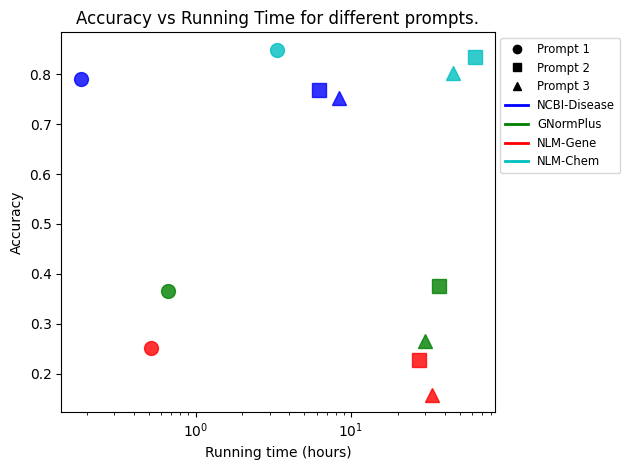

In [ ]:
# prompt 1 : base 
# prompt 2 : reasoning
# prompt 3 : reasoning model

ncbi_acc = [0.791, 0.769, 0.753] 
ncbi_time = [11/60, 6+15/60, 8+20/60]

gnormplus_acc = [0.365, 0.376, 0.265]
gnormplus_time = [40/60, 36+35/60, 29+56/60]

nlmgene_acc = [0.251, 0.228, 0.158]
nlmgene_time = [31/60, 27+22/60, 33+1/60]

nlmchem_acc = [0.849, 0.834, 0.802]
nlmchem_time = [3+21/60 , 62+36/60, 45+37/60]

# Markers for each point index
markers = ['o', 's', '^']  # markers = ['o', 'x', 's', '^', 'D']  # Circle, cross, square, triangle, diamond
marker_meanings = ['Prompt 1', 'Prompt 2', 'Prompt 3']
colors = ['b', 'g', 'r', 'c']
colors_meanings = ['NCBI-Disease', 'GNormPlus', 'NLM-Gene', 'NLM-Chem']

# Create figure and axes
fig, ax = plt.subplots()

# # Plot entire curves to connect the points with lines
# ax.plot(ncbi_time, ncbi_acc, color=colors[0], linestyle='-', label='NCBI-Disease')
# ax.plot(gnormplus_time, gnormplus_acc, color=colors[1], linestyle='-', label='GNormPlus')
# ax.plot(nlmgene_time, nlmgene_acc, color=colors[2], linestyle='-', label='NLM-Gene')
# ax.plot(nlmchem_time, nlmchem_acc, color=colors[3], linestyle='-', label='NLM-Chem')

# Plot each point separately with shared markers for the same index across curves
for i in range(len(ncbi_acc)):
    ax.plot(ncbi_time[i], ncbi_acc[i], marker=markers[i], color=colors[0], linestyle='None', alpha=0.8, markersize=10)
    ax.plot(gnormplus_time[i], gnormplus_acc[i], marker=markers[i], color=colors[1], linestyle='None', alpha=0.8, markersize=10)
    ax.plot(nlmgene_time[i], nlmgene_acc[i], marker=markers[i], color=colors[2], linestyle='None', alpha=0.8, markersize=10)
    ax.plot(nlmchem_time[i], nlmchem_acc[i], marker=markers[i], color=colors[3], linestyle='None', alpha=0.8, markersize=10)


# Add separate legend entries for each marker type
for i, meaning in enumerate(marker_meanings):
    ax.plot([], [], marker=markers[i], color='black', linestyle='None', label=meaning)

# Add separate legend entries for each marker type
for i, meaning in enumerate(colors_meanings):
    ax.plot([], [], color=colors[i], linestyle='-', linewidth=2, label=meaning)
    
# Adding labels and title
ax.set_xlabel('Running time (hours)')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs Running Time for different prompts.')
ax.set_xscale('log')

# Adding a legend
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')

# Display the plot
plt.show()
